In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as stats
from matplotlib import pyplot as plt 
from scipy.stats import ttest_ind   
from scipy.stats import chi2_contingency
pd.options.display.max_columns = 100

In [43]:
def fetch_diabetes_hospital(*, as_frame=True, cache=True, data_home=None, return_X_y=False):
    """Load the preprocessed Diabetes 130-Hospitals dataset (binary classification).

    Download it if necessary.

    ==============   ============================
    Samples total                          101766
    Dimensionality                             24
    Features         numeric, categorical, string
    Classes                                     2
    ==============   ============================

    Source: UCI Repository :footcite:`strack2014diabetes`
    Paper: Strack et al., 2014 :footcite:`strack2014impact`

    The "Diabetes 130-Hospitals" dataset represents 10 years of clinical care at 130
    U.S. hospitals and delivery networks, collected from 1999 to 2008. Each record
    represents the hospital admission record for a patient diagnosed with diabetes
    whose stay lasted between one to fourteen days.

    The original "Diabetes 130-Hospitals" dataset was collected by Beata Strack,
    Jonathan P. DeShazo, Chris Gennings, Juan L. Olmo, Sebastian Ventura,
    Krzysztof J. Cios, and John N. Clore in 2014.

    This version of the dataset was derived by the Fairlearn team for the SciPy
    2021 tutorial "Fairness in AI Systems: From social context to practice using
    Fairlearn". In this version, the target variable "readmitted" is binarized
    into whether the patient was re-admitted within thirty days. The full
    pre-processing script is available
    `here <https://github.com/fairlearn/talks/blob/main/2021_scipy_tutorial/preprocess.py>`_.

    Read more in the :ref:`User Guide <diabetes_hospital_data>`.

    .. versionadded:: 0.8.0

    Parameters
    ----------
    as_frame : bool, default=True
        If True, the data is a pandas DataFrame including columns with
        appropriate dtypes (numeric, string or categorical).

        .. note::
            If set to False, this will raise an exception because of a type mismatch
            in the OpenML dataset.

        .. versionadded:: 0.9.0

    cache : bool, default=True
        Whether to cache downloaded datasets using joblib.

    data_home : str, default=None
        Specify another download and cache folder for the datasets.
        By default, all fairlearn data is stored in '~/.fairlearn-data'
        subfolders.

    return_X_y : bool, default=False
        If True, returns ``(data.data, data.target)`` instead of a Bunch
        object.

    Returns
    -------
    dataset : :obj:`~sklearn.utils.Bunch`
        Dictionary-like object, with the following attributes:

        data : ndarray, shape (101766, 24)
            Each row corresponding to the 24 feature values in order.
            If ``as_frame`` is True, ``data`` is a pandas object.
        target : numpy array of shape (101766,)
            Each value represents whether readmission of the patient
            occurred within 30 days of the release.
        feature_names : list of length 24
            Array of ordered feature names used in the dataset.
        DESCR : string
            Description of the Diabetes 130-Hospitals dataset.
        categories : dict or None
            Maps each categorical feature name to a list of values, such that the
            value encoded as i is ith in the list. If ``as_frame`` is True, this is None.
        frame : pandas DataFrame
            Only present when ``as_frame`` is True. DataFrame with ``data`` and ``target``.

    (data, target) : tuple if ``return_X_y`` is True

    Notes
    -----
    Our API largely follows the API of :func:`sklearn.datasets.fetch_openml`.
    """
    if not data_home:
        data_home = pathlib.Path().home() / _DOWNLOAD_DIRECTORY_NAME

    # For data_home see
    # https://github.com/scikit-learn/scikit-learn/issues/27447
    return fetch_openml(
        data_id=43874,
        data_home=str(data_home),
        cache=cache,
        as_frame=as_frame,
        return_X_y=return_X_y,
        parser="auto",
    )

In [44]:
df = pd.read_csv("datos/diabetes.csv")
df.head(10)

,race,gender,age,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,num_medications,primary_diagnosis,number_diagnoses,max_glu_serum,A1Cresult,insulin,change,diabetesMed,medicare,medicaid,had_emergency,had_inpatient_days,had_outpatient_days,readmitted,readmit_binary,readmit_30_days
0,Caucasian,Female,30 years or younger,Other,Referral,1,Other,41,0,1,Diabetes,1,NaN,NaN,No,No,No,False,False,False,False,False,NO,0,0
1,Caucasian,Female,30 years or younger,Discharged to Home,Emergency,3,Missing,59,0,18,Other,9,NaN,NaN,Up,Ch,Yes,False,False,False,False,False,>30,1,0
2,AfricanAmerican,Female,30 years or younger,Discharged to Home,Emergency,2,Missing,11,5,13,Other,6,NaN,NaN,No,No,Yes,False,False,False,True,True,NO,0,0
3,Caucasian,Male,30-60 years,Discharged to Home,Emergency,2,Missing,44,1,16,Other,7,NaN,NaN,Up,Ch,Yes,False,False,False,False,False,NO,0,0
4,Caucasian,Male,30-60 years,Discharged to Home,Emergency,1,Missing,51,0,8,Other,5,NaN,NaN,Steady,Ch,Yes,False,False,False,False,False,NO,0,0
5,Caucasian,Male,30-60 years,Discharged to Home,Referral,3,Missing,31,6,16,Other,9,NaN,NaN,Steady,No,Yes,False,False,False,False,False,>30,1,0
6,Caucasian,Male,Over 60 years,Discharged to Home,Referral,4,Missing,70,1,21,Other,7,NaN,NaN,Steady,Ch,Yes,False,False,False,False,False,NO,0,0
7,Caucasian,Male,Over 60 years,Discharged to Home,Emergency,5,Missing,73,0,12,Other,8,NaN,NaN,No,No,Yes,False,False,False,False,False,>30,1,0
8,Caucasian,Female,Over 60 years,Discharged to Home,Other,13,Missing,68,2,28,Other,8,NaN,NaN,Steady,Ch,Yes,False,False,False,False,False,NO,0,0
9,Caucasian,Female,Over 60 years,Other,Other,12,InternalMedicine,33,3,18,Other,8,NaN,NaN,Steady,Ch,Yes,False,False,False,False,False,NO,0,0


In [45]:
df = df.replace(['Missing','Unknown/Invalid','Unknown'], np.nan)
nulos = df.isnull().sum()
porcentaje = (df.isnull().mean() * 100).round(2)
resumen_nulos = pd.DataFrame({
    "Valores Nulos": nulos,
    "% Nulos": porcentaje
}).sort_values(by="% Nulos", ascending=False)

print(resumen_nulos)


                          Valores Nulos  % Nulos
max_glu_serum                     96420    94.75
A1Cresult                         84748    83.28
medical_specialty                 49949    49.08
race                               2273     2.23
gender                                3     0.00
admission_source_id                   0     0.00
time_in_hospital                      0     0.00
discharge_disposition_id              0     0.00
age                                   0     0.00
num_procedures                        0     0.00
num_lab_procedures                    0     0.00
primary_diagnosis                     0     0.00
num_medications                       0     0.00
number_diagnoses                      0     0.00
insulin                               0     0.00
change                                0     0.00
diabetesMed                           0     0.00
medicare                              0     0.00
medicaid                              0     0.00
had_emergency       

###
 eliminamos los nulos y los missing/unknown ya que al ser un caso médico podría ser relevante

In [46]:
df= df.dropna(axis=0)
df= df.dropna(axis=1)
df =df.fillna(nulos)


###
Comprobamos que este bien

In [47]:
print(df.isnull().sum().sum())

0


###
Como da cero, intuímos que el resultado es correcto

## 2. Analizamos las variables categóricas

In [48]:
cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

for col in df.select_dtypes(include=["float64", "int64"]).columns.tolist():
    if df[col].nunique() == 2:
        cat_cols.append(col)
        
print("Variables categóricas/booleanas:", cat_cols)
    


Variables categóricas/booleanas: ['race', 'gender', 'age', 'discharge_disposition_id', 'admission_source_id', 'medical_specialty', 'primary_diagnosis', 'max_glu_serum', 'A1Cresult', 'insulin', 'change', 'diabetesMed', 'medicare', 'medicaid', 'had_emergency', 'had_inpatient_days', 'had_outpatient_days', 'readmitted', 'readmit_binary', 'readmit_30_days']


###
limpieza inicial de espacios

In [49]:
print(len(col))
for col in cat_cols:
   print(col)
   if df[col].dtype == 'object':
       print(f"Columna: {col}")
       print(df[col].value_counts())
       print("\n")

15
race
Columna: race
race
Caucasian          88
Hispanic           23
AfricanAmerican    22
Other               4
Asian               4
Name: count, dtype: int64


gender
Columna: gender
gender
Female    85
Male      56
Name: count, dtype: int64


age
Columna: age
age
Over 60 years          86
30-60 years            52
30 years or younger     3
Name: count, dtype: int64


discharge_disposition_id
Columna: discharge_disposition_id
discharge_disposition_id
Discharged to Home    90
Other                 51
Name: count, dtype: int64


admission_source_id
Columna: admission_source_id
admission_source_id
Emergency    128
Referral      13
Name: count, dtype: int64


medical_specialty
Columna: medical_specialty
medical_specialty
InternalMedicine    139
Other                 2
Name: count, dtype: int64


primary_diagnosis
Columna: primary_diagnosis
primary_diagnosis
Other                     87
Respiratory Issues        26
Diabetes                  19
Genitourinary Issues       6
Musculoskelet

In [50]:
for col in cat_cols:
    if df[col].dtype == 'object':
        df[col] = df[col].str.strip().str.replace(" ", "_")

###
analisis individualizado de cada variable

In [51]:
for col in cat_cols:
    print(f"\n--- Análisis de {col} ---")
    print("Valores únicos:", df[col].nunique())
    print("Frecuencia de categorías:")
    print((df[col].value_counts(normalize=True) * 100).round(2))



--- Análisis de race ---
Valores únicos: 5
Frecuencia de categorías:
race
Caucasian          62.41
Hispanic           16.31
AfricanAmerican    15.60
Other               2.84
Asian               2.84
Name: proportion, dtype: float64

--- Análisis de gender ---
Valores únicos: 2
Frecuencia de categorías:
gender
Female    60.28
Male      39.72
Name: proportion, dtype: float64

--- Análisis de age ---
Valores únicos: 3
Frecuencia de categorías:
age
Over_60_years          60.99
30-60_years            36.88
30_years_or_younger     2.13
Name: proportion, dtype: float64

--- Análisis de discharge_disposition_id ---
Valores únicos: 2
Frecuencia de categorías:
discharge_disposition_id
Discharged_to_Home    63.83
Other                 36.17
Name: proportion, dtype: float64

--- Análisis de admission_source_id ---
Valores únicos: 2
Frecuencia de categorías:
admission_source_id
Emergency    90.78
Referral      9.22
Name: proportion, dtype: float64

--- Análisis de medical_specialty ---
Valores úni

###
Converimos valores binarios en booleanos

In [52]:
col_to_convert = ['change','diabetesMed']
for col in cat_cols:
    if col in col_to_convert or df[col].dtype == 'int64':
        vals = df[col].unique()
        df[col] = df[col].map({vals[0]: False, vals[1]: True})
       

## Análisis de variables numérica

### 
Sleccionamos las variables numéricas

In [53]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
print("Variables numéricas:", num_cols)


Variables numéricas: ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_diagnoses']


###
y ahora los datos estadísticos descriptivos

In [54]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
time_in_hospital,141.0,5.078014,2.961831,1.0,3.0,4.0,7.0,14.0
num_lab_procedures,141.0,64.588652,14.604828,38.0,53.0,64.0,75.0,102.0
num_procedures,141.0,0.758865,1.101303,0.0,0.0,0.0,1.0,3.0
num_medications,141.0,13.326241,6.574297,2.0,9.0,13.0,16.0,35.0
number_diagnoses,141.0,5.404255,0.978181,1.0,5.0,6.0,6.0,6.0


###
Visualizamos los histogramas y boxplots y además comprobamos los outliers

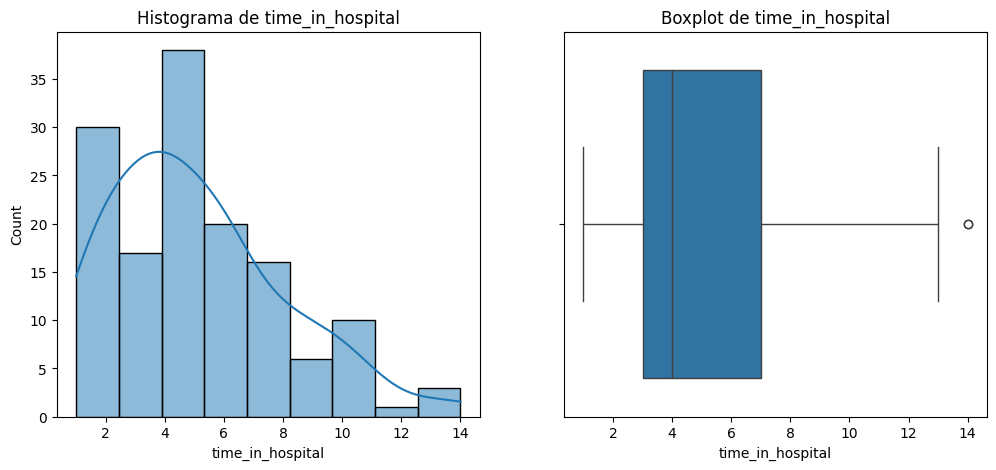

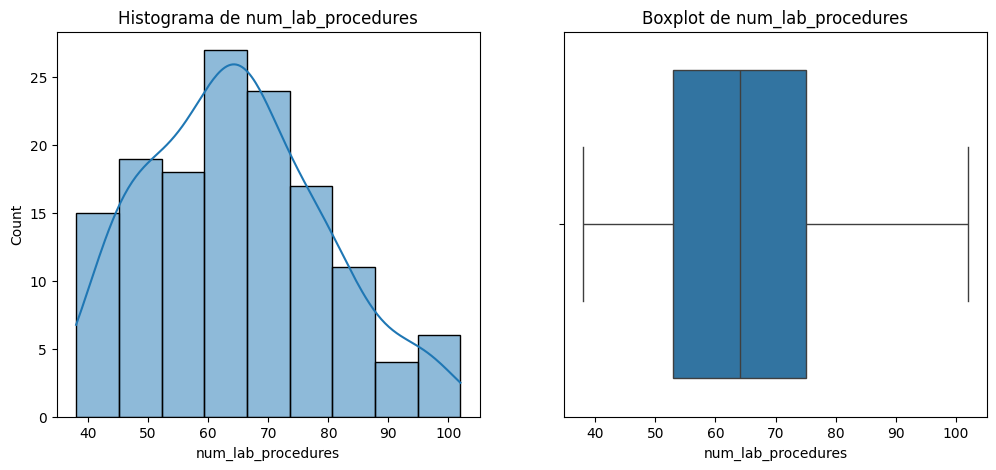

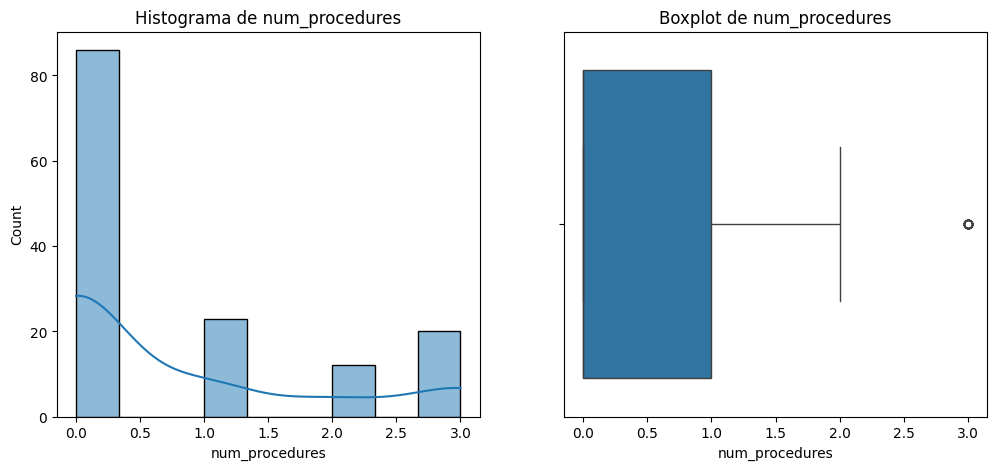

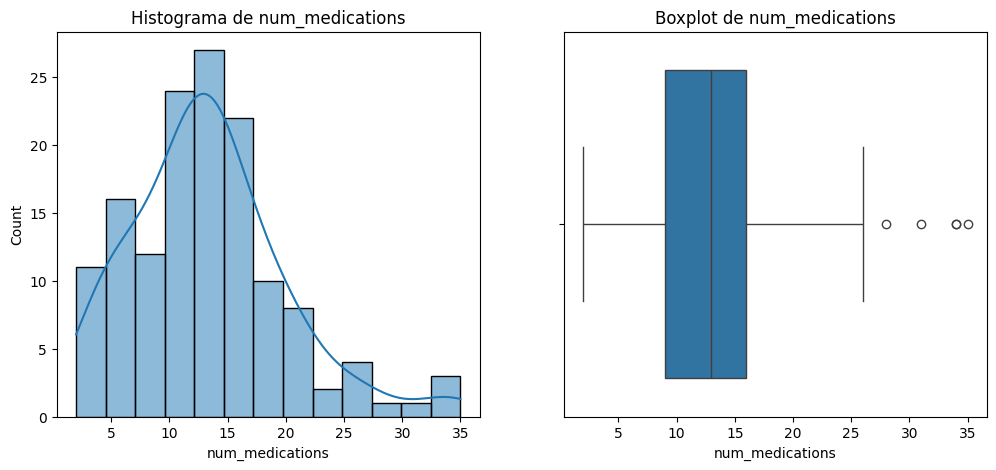

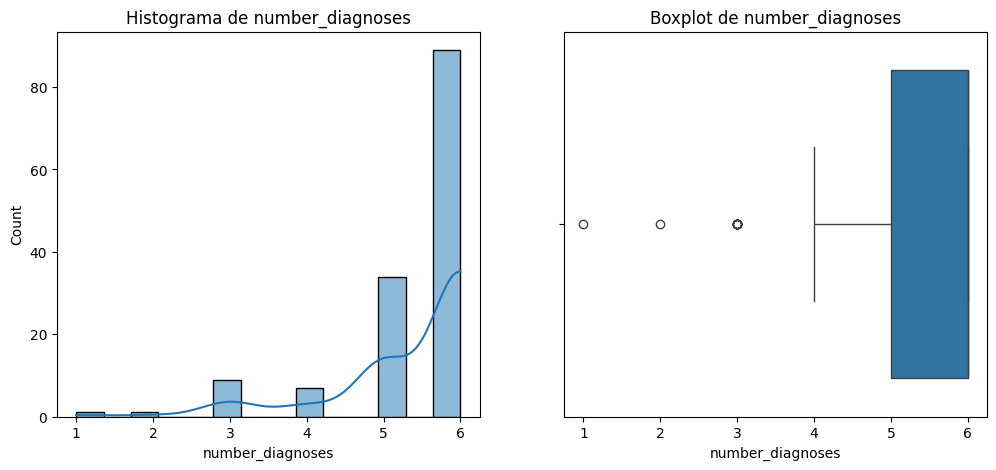

In [55]:

for col in num_cols:
    plt.figure(figsize=(12,5))
    
    # Histograma
    plt.subplot(1,2,1)
    sns.histplot(df[col], kde=True)
    plt.title(f"Histograma de {col}")
    
    # Boxplot
    plt.subplot(1,2,2)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    
    plt.show()


#
Detectamos los oultiers con el rango intercuartil (IQR)

In [56]:
outliers_info = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)][col].count()
    outliers_info[col] = {"Nº outliers": outliers,
                          "% outliers": round(100*outliers/len(df),2)}
    
outliers_df = pd.DataFrame(outliers_info).T
print(outliers_df)


                    Nº outliers  % outliers
time_in_hospital            2.0        1.42
num_lab_procedures          0.0        0.00
num_procedures             20.0       14.18
num_medications             5.0        3.55
number_diagnoses           11.0        7.80


#
tratamos los outliers:
#
Los outliers con porcentaje bajo (1%-2%), los tratamos eliminando las filas.
#
Los outliers con un mayor sesgo le aplicamos el tratamiento logaritmico.
    

In [57]:
THRESH = 2.0
K = 1.5

# 1) Columnas numéricas y límites IQR (vectorizado)
num_cols = df.select_dtypes(include="number").columns
q1 = df[num_cols].quantile(0.25)
q3 = df[num_cols].quantile(0.75)
iqr = q3 - q1
lower = q1 - K * iqr
upper = q3 + K * iqr

# 2) % de outliers por columna
is_out = df[num_cols].lt(lower) | df[num_cols].gt(upper)
outlier_stats_df = (
    pd.DataFrame({
        "col": num_cols,
        "n_outliers": is_out.sum().astype(int).values,
        "pct_outliers": (100 * is_out.mean()).round(3).values
    })
    .sort_values("pct_outliers", ascending=False)
    .reset_index(drop=True)
)
print("Resumen de outliers por columna (IQR):")
display(outlier_stats_df)

# 3) Columnas que usarán para eliminar filas (< THRESH % outliers)
cols_del = outlier_stats_df.loc[outlier_stats_df["pct_outliers"] < THRESH, "col"].tolist()
print(f"\nColumnas donde se eliminarán filas (outliers < {THRESH}%): {cols_del}")

# 4) Filtrado en una sola pasada
if cols_del:
    df_clean = df.loc[
        ((df[cols_del].lt(lower[cols_del]) | df[cols_del].gt(upper[cols_del])).sum(axis=1) == 0)
    ].copy()
else:
    df_clean = df.copy()

print(f"\nFilas iniciales: {len(df)}")
print(f"Filas eliminadas por outliers (<{THRESH}%): {len(df) - len(df_clean)}")
print(f"Filas finales: {len(df_clean)}")

# 5) (Opcional) mostrar límites aplicados
if cols_del:
    print("\nLímites IQR usados para filtrar (por columna):")
    for c in cols_del:
        print(f" - {c}: [{lower[c]:.4f}, {upper[c]:.4f}]")

# Actualizar df
df = df_clean


Resumen de outliers por columna (IQR):


,col,n_outliers,pct_outliers
0,num_procedures,20,14.184
1,number_diagnoses,11,7.801
2,num_medications,5,3.546
3,time_in_hospital,2,1.418
4,num_lab_procedures,0,0.000



Columnas donde se eliminarán filas (outliers < 2.0%): ['time_in_hospital', 'num_lab_procedures']

Filas iniciales: 141
Filas eliminadas por outliers (<2.0%): 2
Filas finales: 139

Límites IQR usados para filtrar (por columna):
 - time_in_hospital: [-3.0000, 13.0000]
 - num_lab_procedures: [20.0000, 108.0000]


In [58]:
import numpy as np
df["number_diagnoses_log"] = np.log1p(df["number_diagnoses"])
df["readmit_30_days"] = np.log1p(df["readmit_30_days"]).astype("float32")

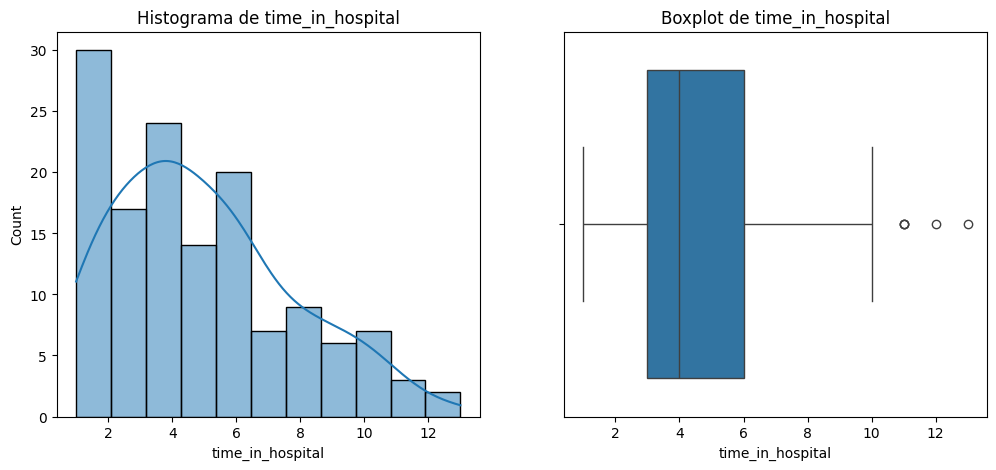

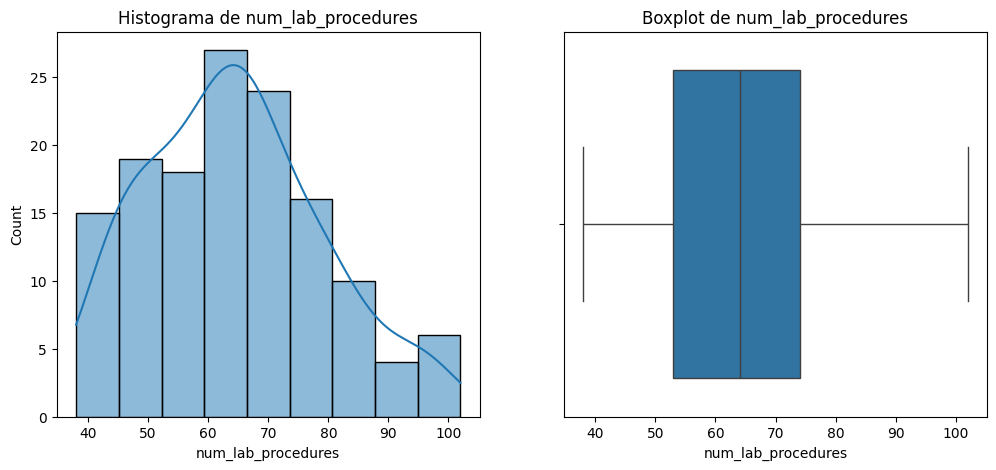

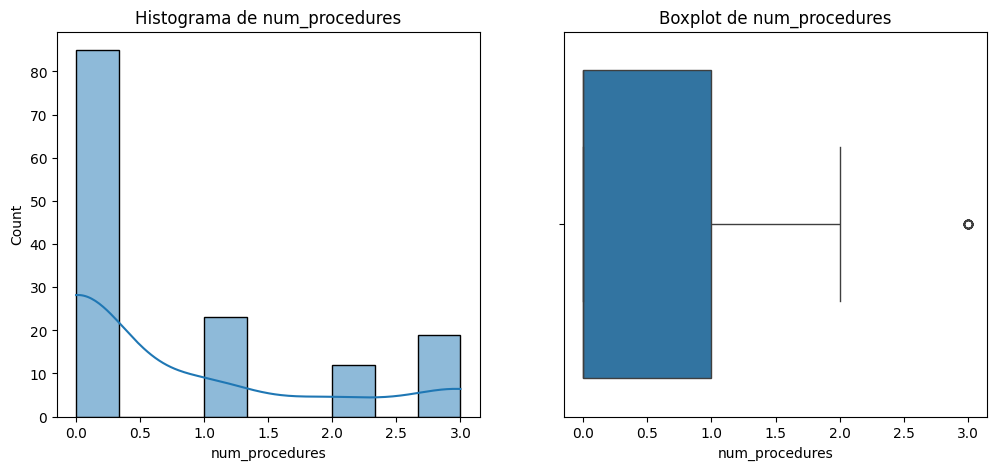

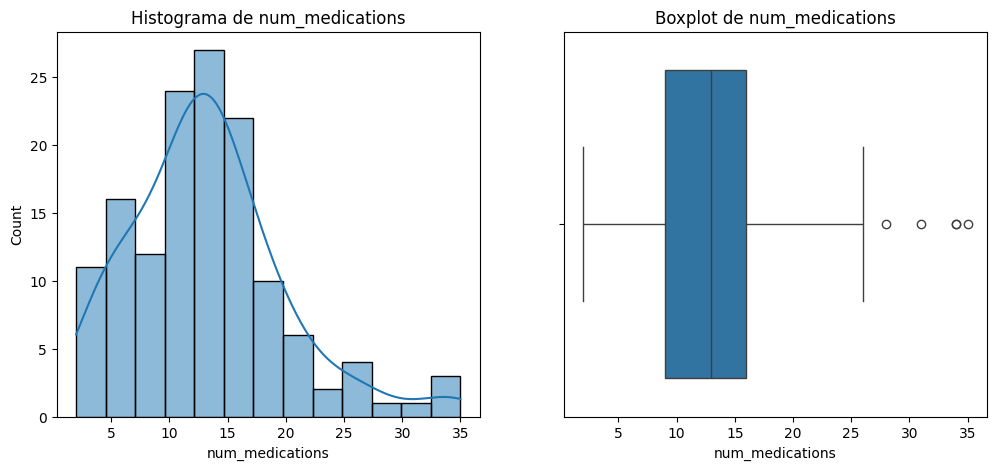

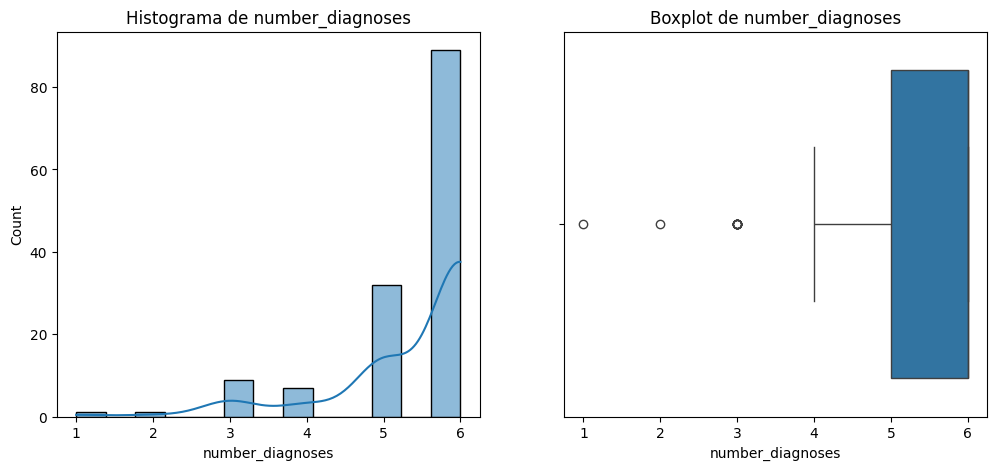

In [59]:

for col in num_cols:
    plt.figure(figsize=(12,5))
    
    # Histograma
    plt.subplot(1,2,1)
    sns.histplot(df[col], kde=True)
    plt.title(f"Histograma de {col}")
    
    # Boxplot
    plt.subplot(1,2,2)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    
    plt.show()


## Analisis multivariante

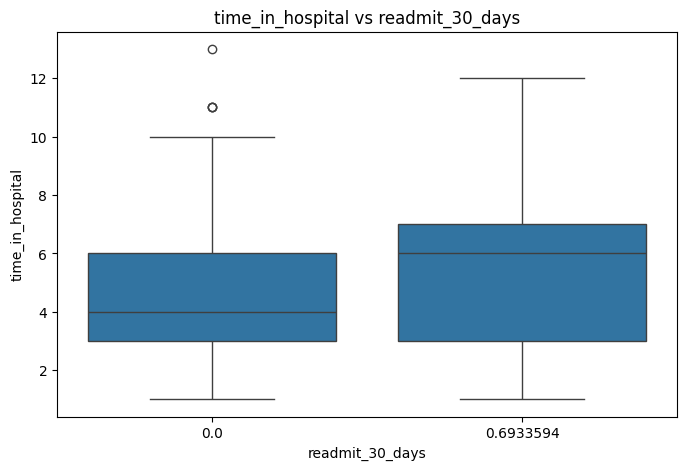

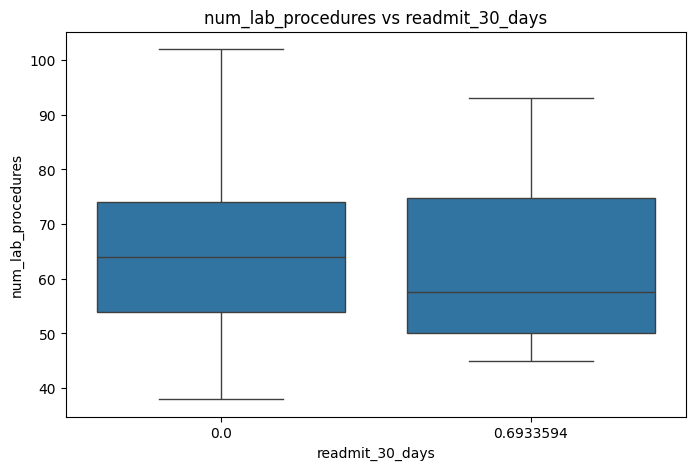

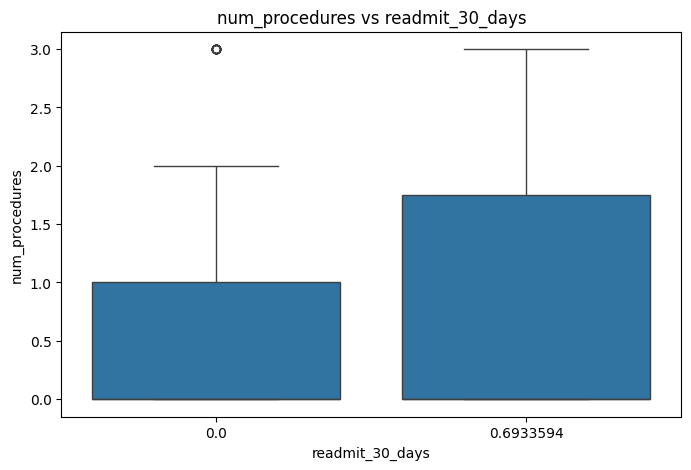

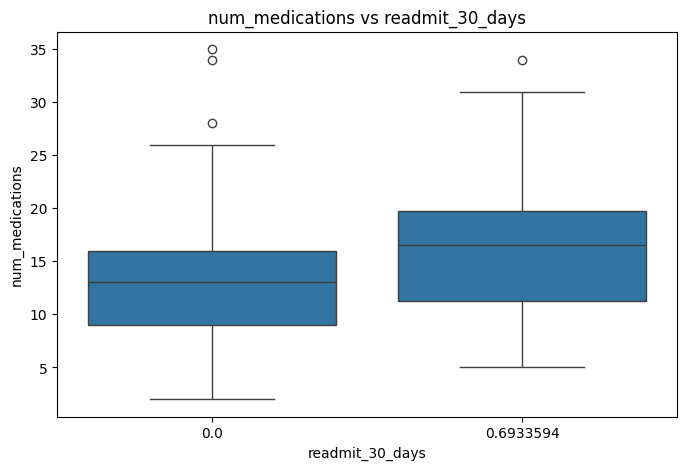

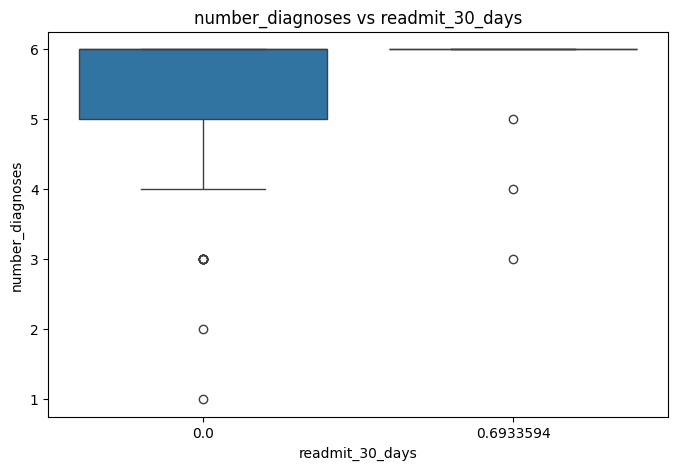

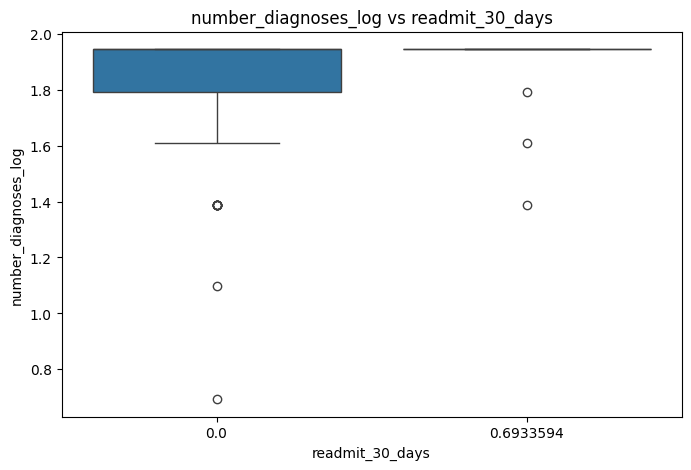

In [60]:
num_cols = df_clean.select_dtypes(include=["number"]).drop(columns=["readmit_30_days"]).columns

for col in num_cols:
    plt.figure(figsize=(8,5))
    sns.boxplot(x="readmit_30_days", y=col, data=df_clean)
    plt.title(f"{col} vs readmit_30_days")
    plt.show()


###
comparamos con t-test

In [73]:
for col in num_cols:
    grupo0 = df_clean[df_clean["readmit_30_days"] == 0][col]
    grupo1 = df_clean[df_clean["readmit_30_days"] == 1][col]
    stat, p = ttest_ind(grupo0, grupo1, equal_var=False)
    print(f"{col}: p-value={p:.4f}")

time_in_hospital: p-value=nan
num_lab_procedures: p-value=nan
num_procedures: p-value=nan
num_medications: p-value=nan
number_diagnoses: p-value=nan
number_diagnoses_log: p-value=nan


C:\Users\Surface\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


#
time_in_hospital: p-value=0.0258 #significativo
#
num_lab_procedures: p-value=0.4971 #nosgnificativo
#
num_procedures: p-value=0.0724 #nosignificativo
#
num_medications: p-value=0.0236 #significativo
#
number_diagnoses: p-value=0.7570 #nosignificativo
#
readmit_binary: p-value=0.0000 #muysignificativo

###para saber si el resultado es significativo o no, se compara el p-value con un umbral (comúnmente 0.05). Si el p-value es menor que el umbral, se considera que hay una diferencia significativa entre los grupos.###

## 
variable categorica vs variable objetivo


--- race ---
readmit_30_days  0.000000  0.693359
race                               
AfricanAmerican  0.909091  0.090909
Asian            0.750000  0.250000
Caucasian        0.895349  0.104651
Hispanic         0.913043  0.086957
Other            1.000000  0.000000


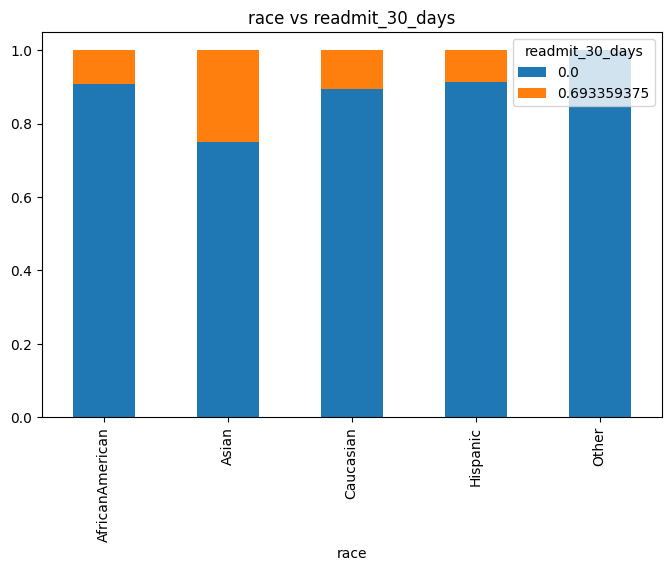


--- gender ---
readmit_30_days  0.000000  0.693359
gender                             
Female           0.869048  0.130952
Male             0.945455  0.054545


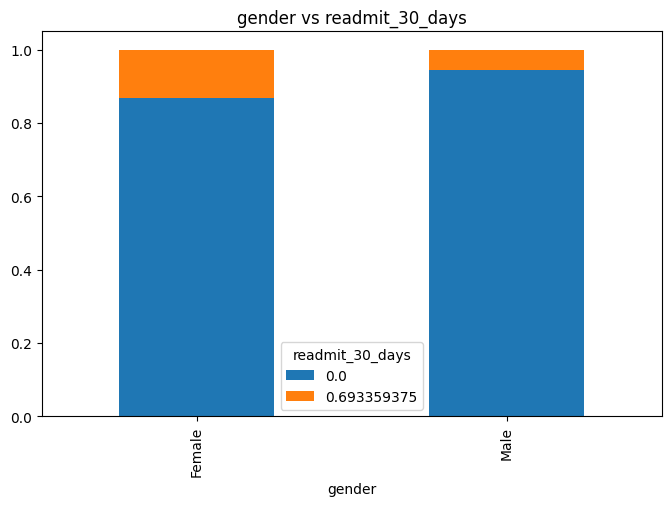


--- age ---
readmit_30_days      0.000000  0.693359
age                                    
30-60_years          0.941176  0.058824
30_years_or_younger  1.000000  0.000000
Over_60_years        0.870588  0.129412


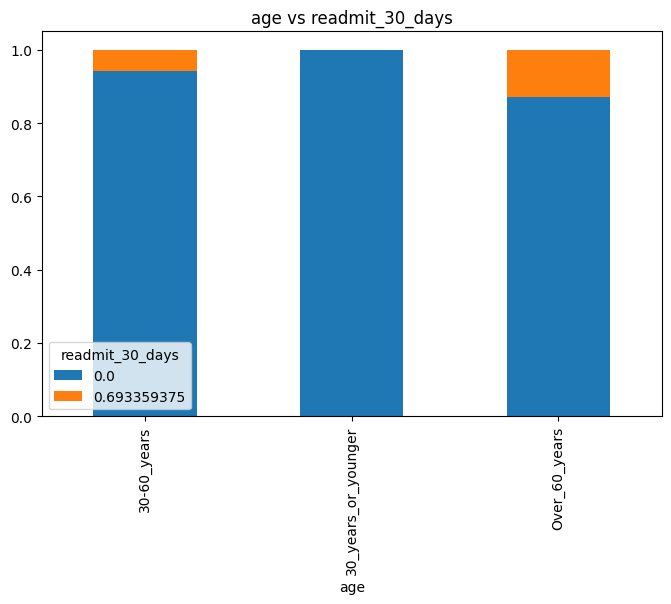


--- discharge_disposition_id ---
readmit_30_days           0.000000  0.693359
discharge_disposition_id                    
Discharged_to_Home        0.955056  0.044944
Other                     0.800000  0.200000


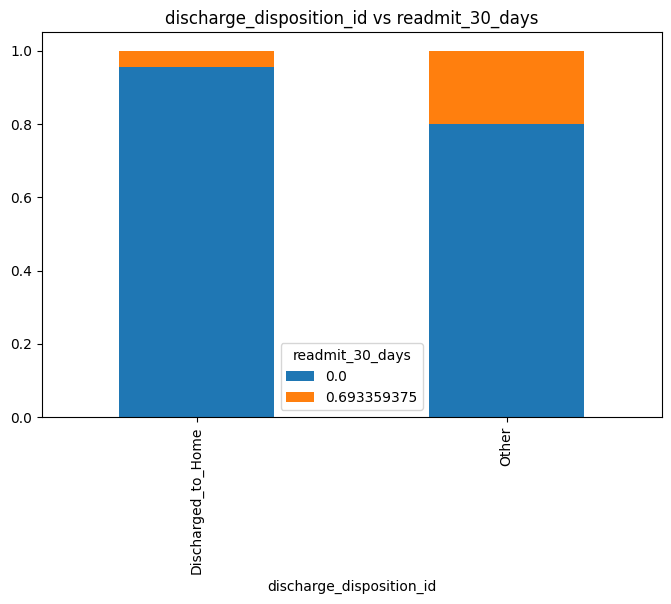


--- admission_source_id ---
readmit_30_days      0.000000  0.693359
admission_source_id                    
Emergency            0.896825  0.103175
Referral             0.923077  0.076923


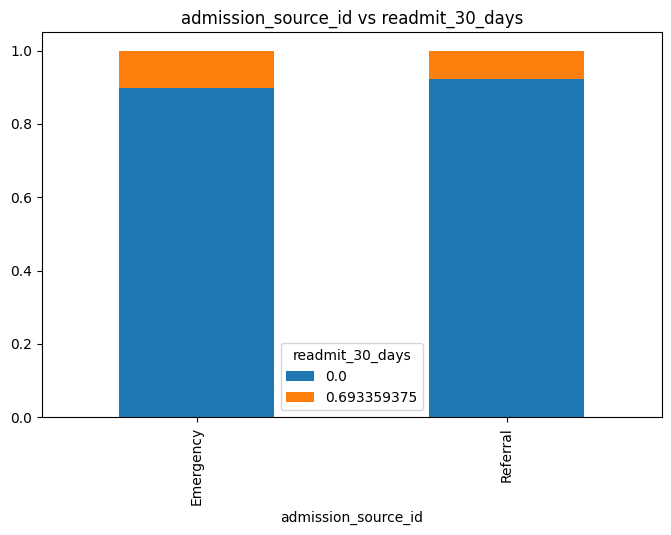


--- medical_specialty ---
readmit_30_days    0.000000  0.693359
medical_specialty                    
InternalMedicine    0.89781   0.10219
Other               1.00000   0.00000


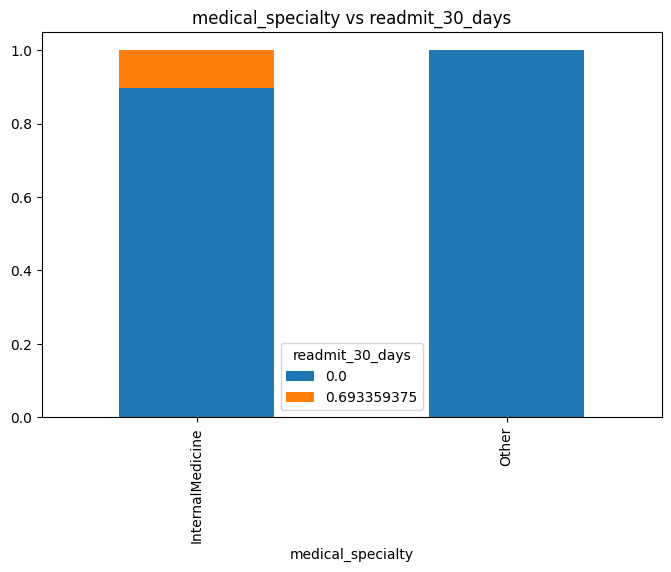


--- primary_diagnosis ---
readmit_30_days         0.000000  0.693359
primary_diagnosis                         
Diabetes                0.944444  0.055556
Genitourinary_Issues    1.000000  0.000000
Musculoskeletal_Issues  1.000000  0.000000
Other                   0.883721  0.116279
Respiratory_Issues      0.884615  0.115385


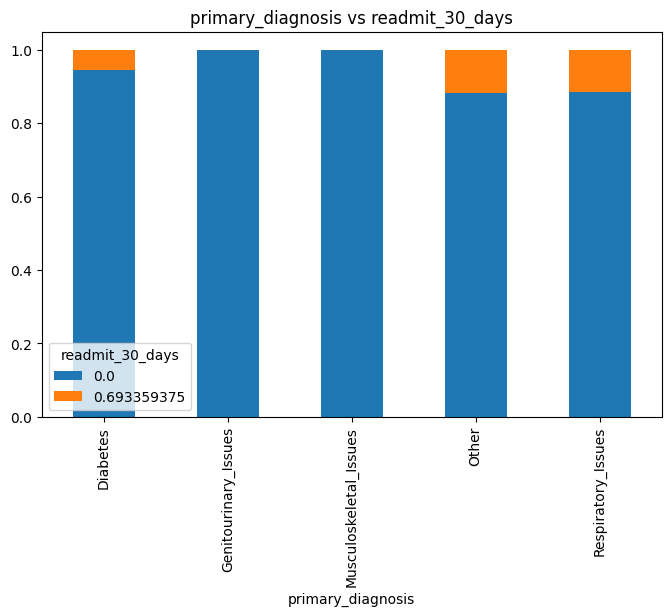


--- max_glu_serum ---
readmit_30_days  0.000000  0.693359
max_glu_serum                      
>200             0.888889  0.111111
>300             0.883721  0.116279
Norm             0.921569  0.078431


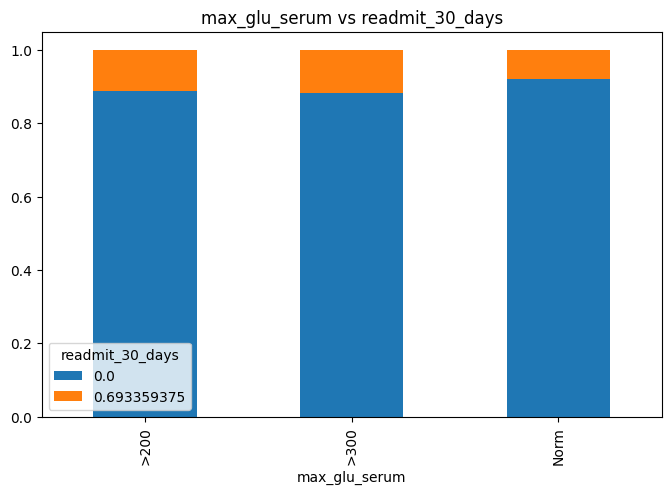


--- A1Cresult ---
readmit_30_days  0.000000  0.693359
A1Cresult                          
>7               0.931034  0.068966
>8               0.900000  0.100000
Norm             0.866667  0.133333


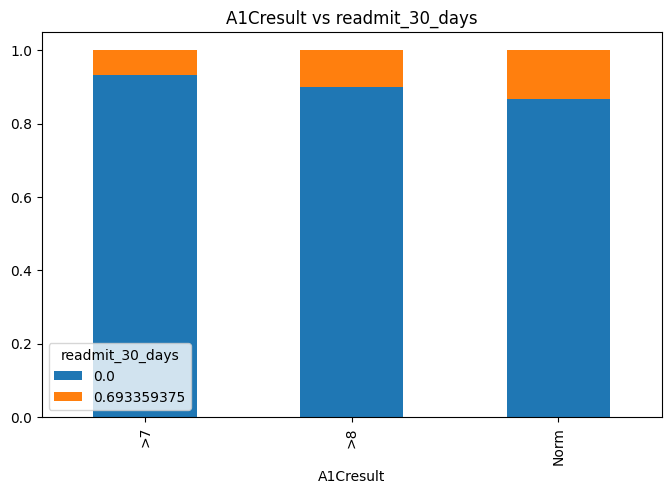


--- insulin ---
readmit_30_days  0.000000  0.693359
insulin                            
Down             0.875000  0.125000
No               0.912088  0.087912
Steady           0.909091  0.090909
Up               0.714286  0.285714


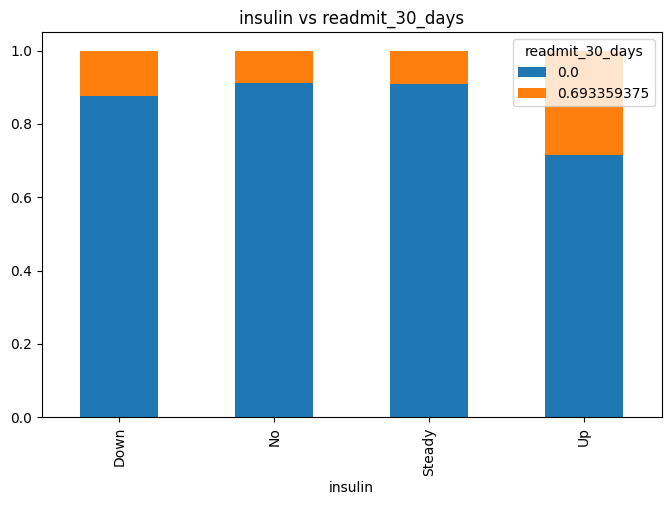


--- change ---
readmit_30_days  0.000000  0.693359
change                             
False            0.903846  0.096154
True             0.885714  0.114286


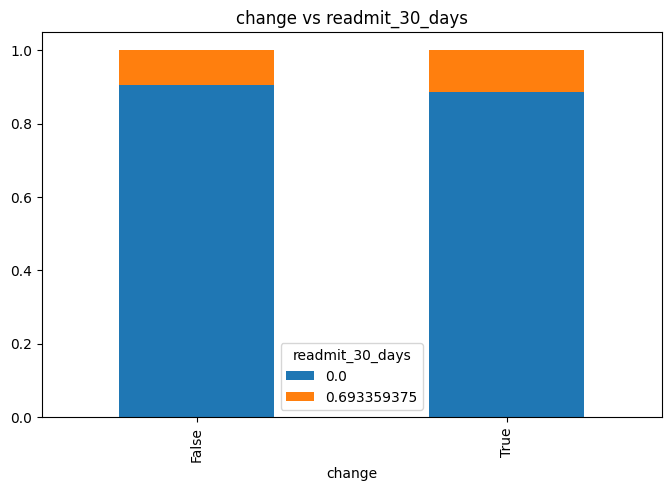


--- diabetesMed ---
readmit_30_days  0.000000  0.693359
diabetesMed                        
False            0.888889  0.111111
True             0.905882  0.094118


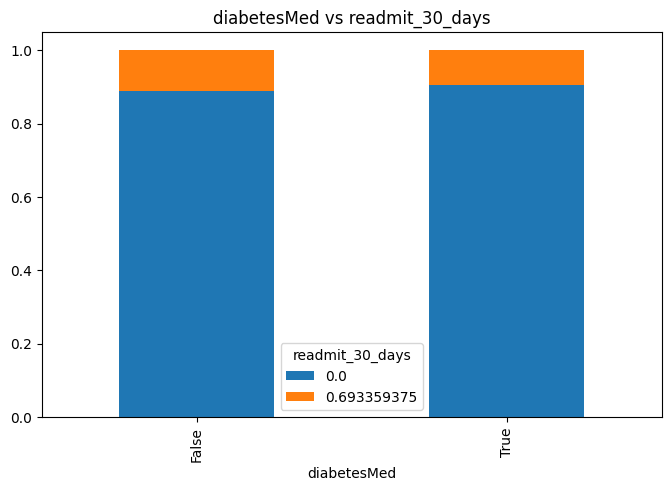


--- medicare ---
readmit_30_days  0.000000  0.693359
medicare                           
False            0.899281  0.100719


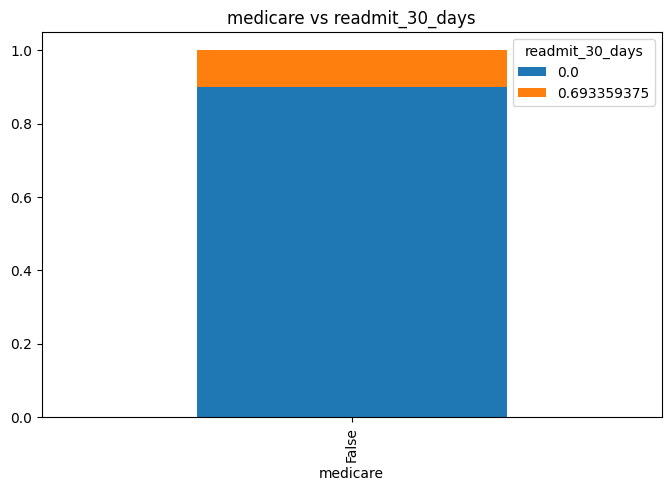


--- medicaid ---
readmit_30_days  0.000000  0.693359
medicaid                           
False            0.899281  0.100719


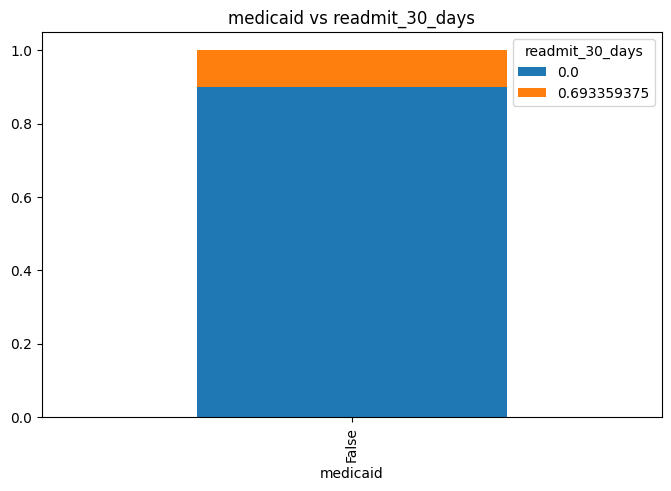


--- had_emergency ---
readmit_30_days  0.000000  0.693359
had_emergency                      
False            0.898551  0.101449
True             1.000000  0.000000


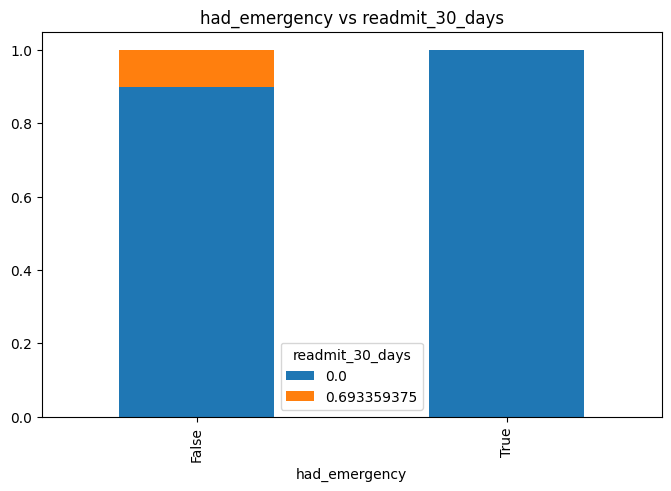


--- had_inpatient_days ---
readmit_30_days     0.000000  0.693359
had_inpatient_days                    
False               0.919192  0.080808
True                0.850000  0.150000


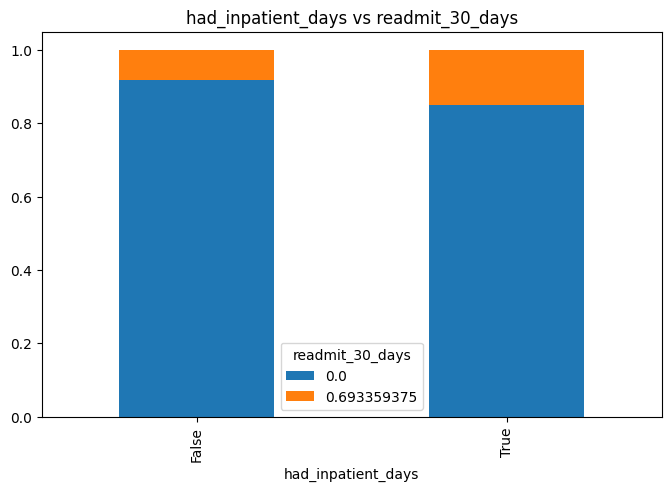


--- had_outpatient_days ---
readmit_30_days      0.000000  0.693359
had_outpatient_days                    
False                0.905109  0.094891
True                 0.500000  0.500000


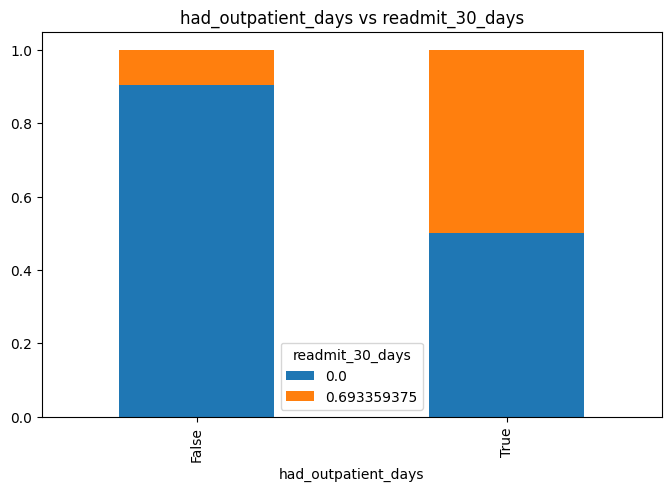


--- readmitted ---
readmit_30_days  0.000000  0.693359
readmitted                         
<30                   0.0       1.0
>30                   1.0       0.0
NO                    1.0       0.0


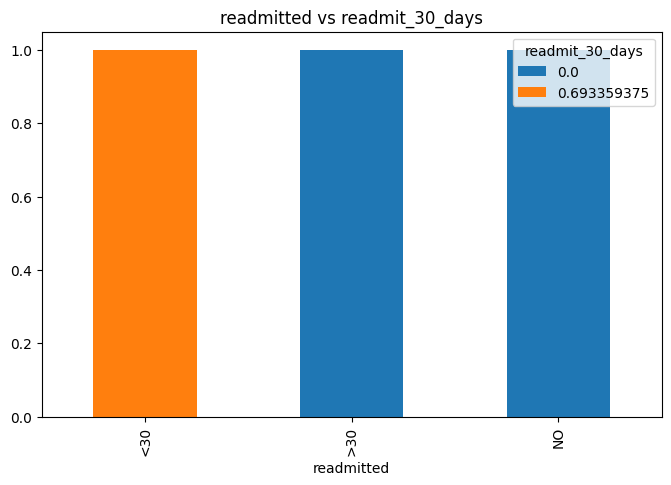


--- readmit_binary ---
readmit_30_days  0.000000  0.693359
readmit_binary                     
False               0.825     0.175
True                1.000     0.000


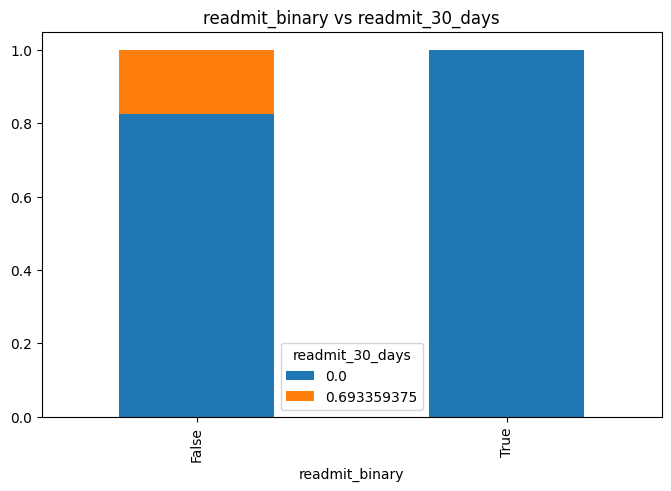

In [62]:
cat_cols = df_clean.select_dtypes(include=["object", "category", "bool"]).columns

for col in cat_cols:
    tabla = pd.crosstab(df_clean[col], df_clean["readmit_30_days"], normalize="index")
    print(f"\n--- {col} ---")
    print(tabla)
    tabla.plot(kind="bar", stacked=True, figsize=(8,5))
    plt.title(f"{col} vs readmit_30_days")
    plt.show()


### 
comprobamos si hay correlación de variables numéricas

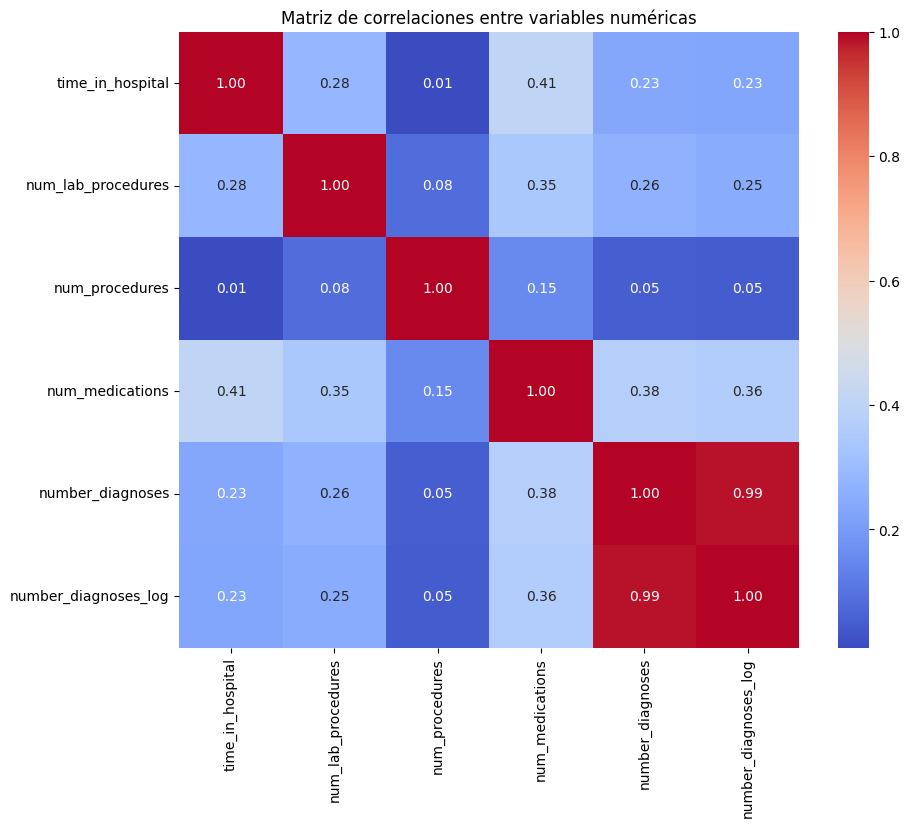

In [63]:
corr = df_clean[num_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlaciones entre variables numéricas")
plt.show()


#
### **Conclusiones**
La matriz de correlación muestra una correlación casi perfecta entre number_diagnoses y su transformación **number_diagnoses_log (r = 0.99)**, lo que implica redundancia; en fases posteriores convendría quedarse solo con una de ellas. El resto de correlaciones son bajas o moderadas: por ejemplo, time_in_hospital, num_lab_procedures y number_diagnoses mantienen una relación positiva con num_medications, lo cual resulta clínicamente coherente. **No se detecta multicolinealidad problemática (r > 0.8) salvo en el caso ya comentado, por lo que no sería necesario descartar más variables numéricas.**

#
 Test Chi


--- race ---
readmit_30_days  0.000000  0.693359
race                               
AfricanAmerican        20         2
Asian                   3         1
Caucasian              77         9
Hispanic               21         2
Other                   4         0
p-value = 0.8234


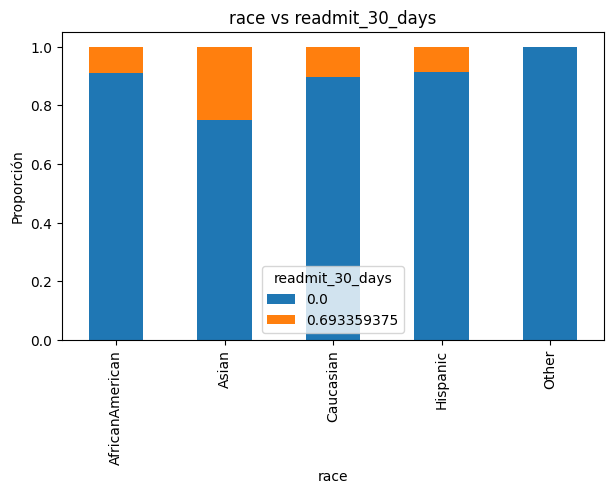


--- gender ---
readmit_30_days  0.000000  0.693359
gender                             
Female                 73        11
Male                   52         3
p-value = 0.2398


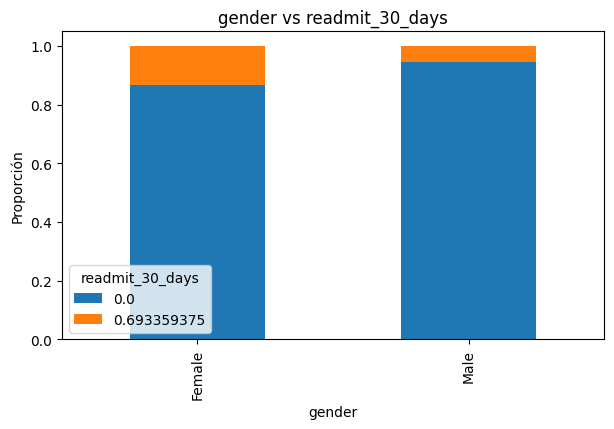


--- age ---
readmit_30_days      0.000000  0.693359
age                                    
30-60_years                48         3
30_years_or_younger         3         0
Over_60_years              74        11
p-value = 0.3505


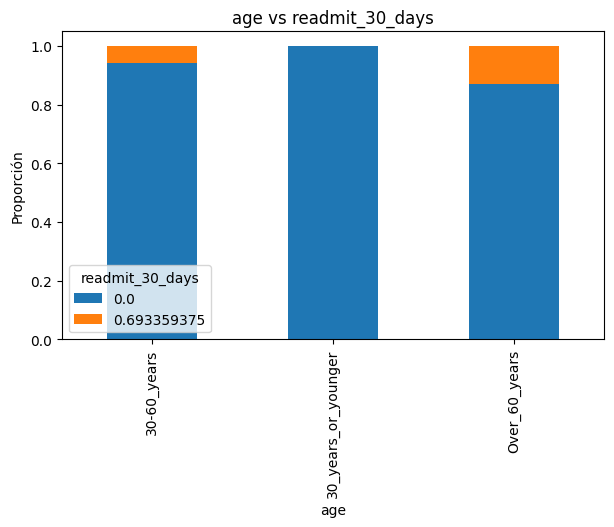


--- discharge_disposition_id ---
readmit_30_days           0.000000  0.693359
discharge_disposition_id                    
Discharged_to_Home              85         4
Other                           40        10
p-value = 0.0088


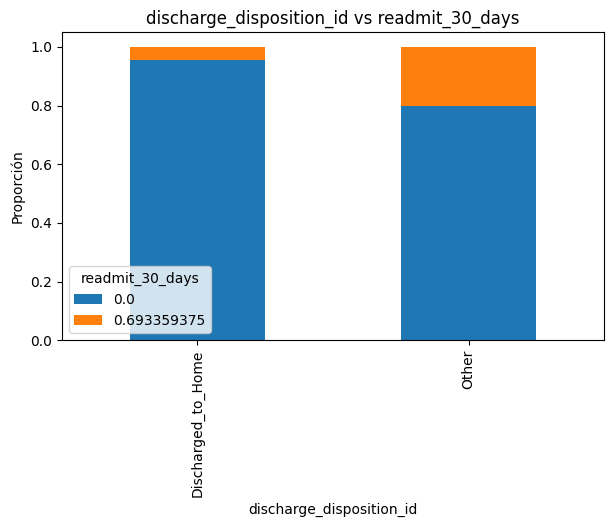


--- admission_source_id ---
readmit_30_days      0.000000  0.693359
admission_source_id                    
Emergency                 113        13
Referral                   12         1
p-value = 1.0000


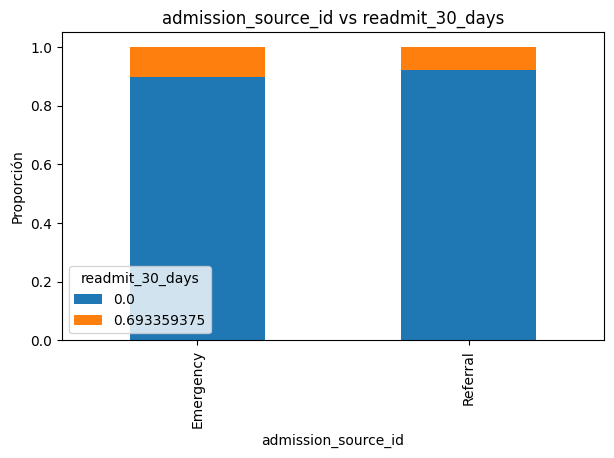


--- medical_specialty ---
readmit_30_days    0.000000  0.693359
medical_specialty                    
InternalMedicine        123        14
Other                     2         0
p-value = 1.0000


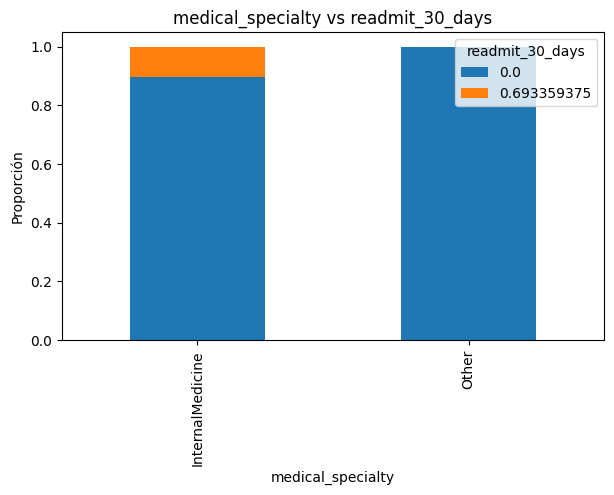


--- primary_diagnosis ---
readmit_30_days         0.000000  0.693359
primary_diagnosis                         
Diabetes                      17         1
Genitourinary_Issues           6         0
Musculoskeletal_Issues         3         0
Other                         76        10
Respiratory_Issues            23         3
p-value = 0.7898


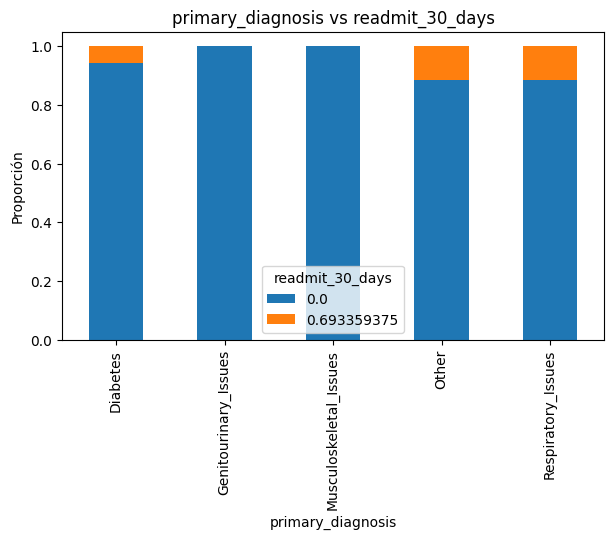


--- max_glu_serum ---
readmit_30_days  0.000000  0.693359
max_glu_serum                      
>200                   40         5
>300                   38         5
Norm                   47         4
p-value = 0.7992


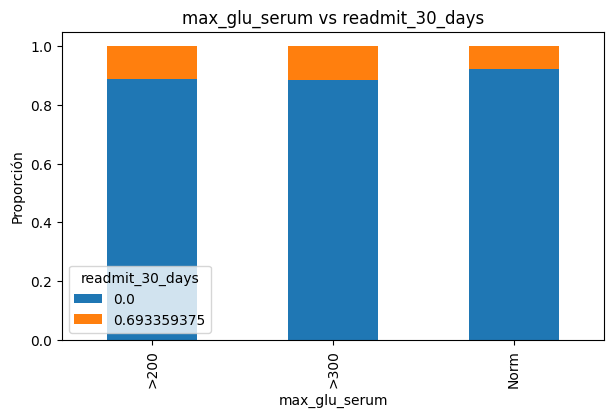


--- A1Cresult ---
readmit_30_days  0.000000  0.693359
A1Cresult                          
>7                     27         2
>8                     72         8
Norm                   26         4
p-value = 0.7133


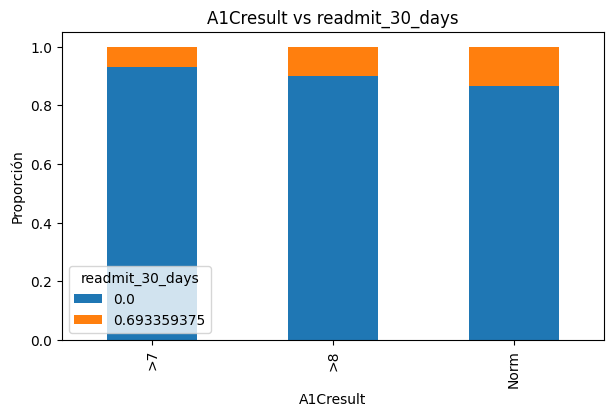


--- insulin ---
readmit_30_days  0.000000  0.693359
insulin                            
Down                    7         1
No                     83         8
Steady                 30         3
Up                      5         2
p-value = 0.4078


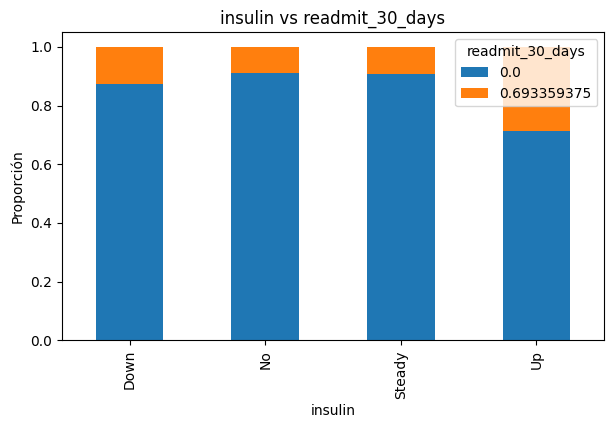


--- change ---
readmit_30_days  0.000000  0.693359
change                             
False                  94        10
True                   31         4
p-value = 1.0000


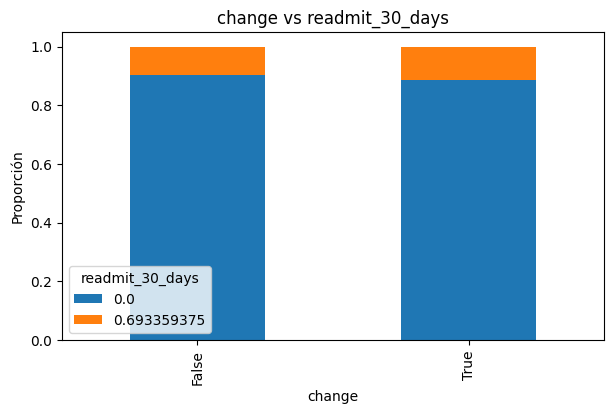


--- diabetesMed ---
readmit_30_days  0.000000  0.693359
diabetesMed                        
False                  48         6
True                   77         8
p-value = 0.9718


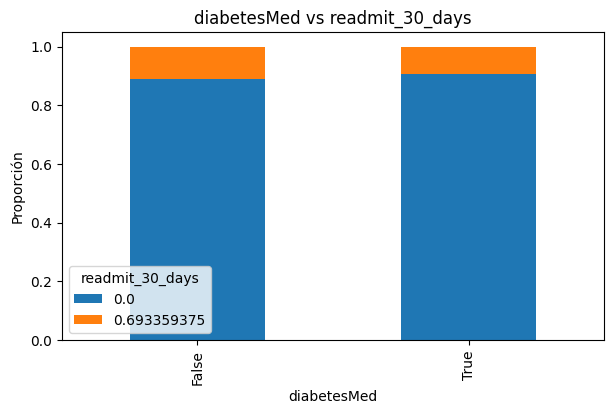


--- medicare ---
readmit_30_days  0.000000  0.693359
medicare                           
False                 125        14
p-value = 1.0000


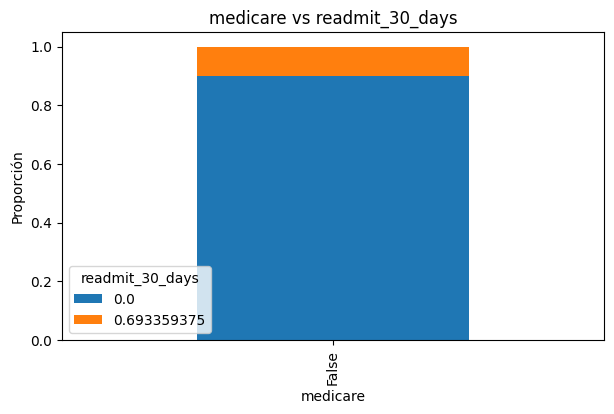


--- medicaid ---
readmit_30_days  0.000000  0.693359
medicaid                           
False                 125        14
p-value = 1.0000


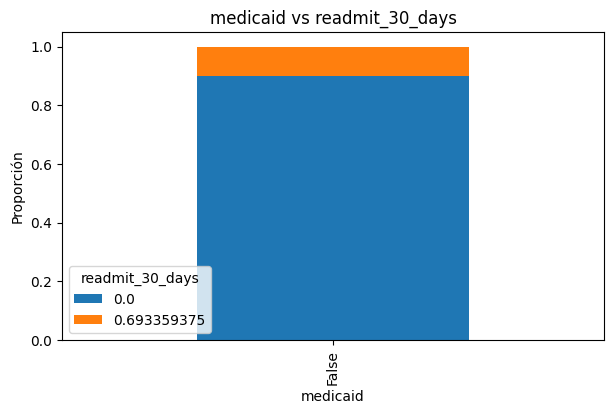


--- had_emergency ---
readmit_30_days  0.000000  0.693359
had_emergency                      
False                 124        14
True                    1         0
p-value = 1.0000


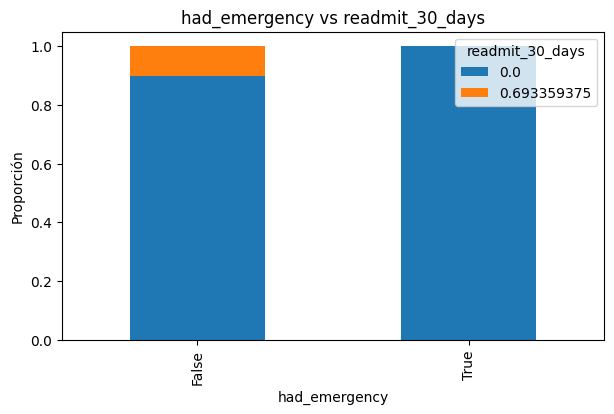


--- had_inpatient_days ---
readmit_30_days     0.000000  0.693359
had_inpatient_days                    
False                     91         8
True                      34         6
p-value = 0.3597


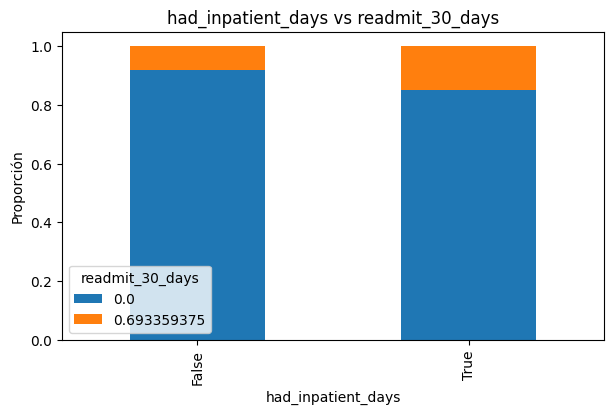


--- had_outpatient_days ---
readmit_30_days      0.000000  0.693359
had_outpatient_days                    
False                     124        13
True                        1         1
p-value = 0.4798


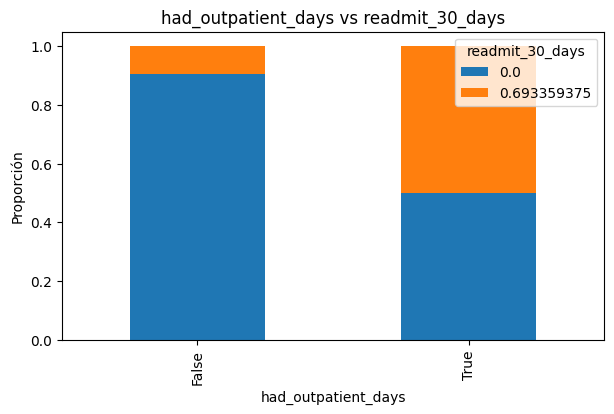


--- readmitted ---
readmit_30_days  0.000000  0.693359
readmitted                         
<30                     0        14
>30                    66         0
NO                     59         0
p-value = 0.0000


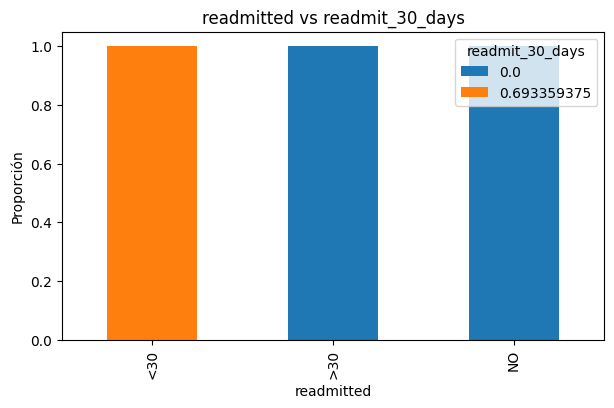


--- readmit_binary ---
readmit_30_days  0.000000  0.693359
readmit_binary                     
False                  66        14
True                   59         0
p-value = 0.0019


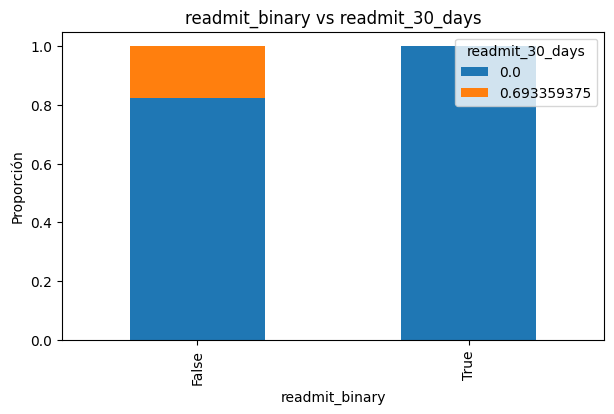


Resumen de resultados chi²:
                         col  p-value
17                readmitted   0.0000
18            readmit_binary   0.0019
3   discharge_disposition_id   0.0088
1                     gender   0.2398
2                        age   0.3505
15        had_inpatient_days   0.3597
9                    insulin   0.4078
16       had_outpatient_days   0.4798
8                  A1Cresult   0.7133
6          primary_diagnosis   0.7898
7              max_glu_serum   0.7992
0                       race   0.8234
11               diabetesMed   0.9718
10                    change   1.0000
4        admission_source_id   1.0000
5          medical_specialty   1.0000
14             had_emergency   1.0000
13                  medicaid   1.0000
12                  medicare   1.0000


In [64]:


# Seleccionar variables categóricas
cat_cols = df_clean.select_dtypes(include=["object", "category", "bool"]).columns

resultados_chi2 = []

for col in cat_cols:
    tabla = pd.crosstab(df_clean[col], df_clean["readmit_30_days"])
    chi2, p, dof, exp = chi2_contingency(tabla)
    
    resultados_chi2.append({"col": col, "p-value": round(p, 4)})
    
    # Mostrar tabla y gráfico
    print(f"\n--- {col} ---")
    print(tabla)
    print(f"p-value = {p:.4f}")
    
    tabla_norm = pd.crosstab(df_clean[col], df_clean["readmit_30_days"], normalize="index")
    tabla_norm.plot(kind="bar", stacked=True, figsize=(7,4))
    plt.title(f"{col} vs readmit_30_days")
    plt.ylabel("Proporción")
    plt.show()

# Resumen final de resultados
res_chi2_df = pd.DataFrame(resultados_chi2).sort_values("p-value")
print("\nResumen de resultados chi²:")
print(res_chi2_df)


###
El análisis bivariante entre variables categóricas y el objetivo **readmit_30_days** evidencia que únicamente unas pocas variables presentan relación significativa. En particular, el tipo de alta hospitalaria **(discharge_disposition_id)** influye de manera estadísticamente significativa en la probabilidad de reingreso. El resto de variables categóricas, como factores demográficos **(age, gender, race)** o clínicos **(insulin, A1Cresult, diabetesMed)**, no muestran asociación relevante con el reingreso en este conjunto de datos.

### Numérica vs Numérica

In [65]:
num_cols = df_clean.select_dtypes(include=["number"]).drop(columns=["readmit_30_days"]).columns
print("Variables numéricas:", num_cols)


Variables numéricas: Index(['time_in_hospital', 'num_lab_procedures', 'num_procedures',
       'num_medications', 'number_diagnoses', 'number_diagnoses_log'],
      dtype='object')


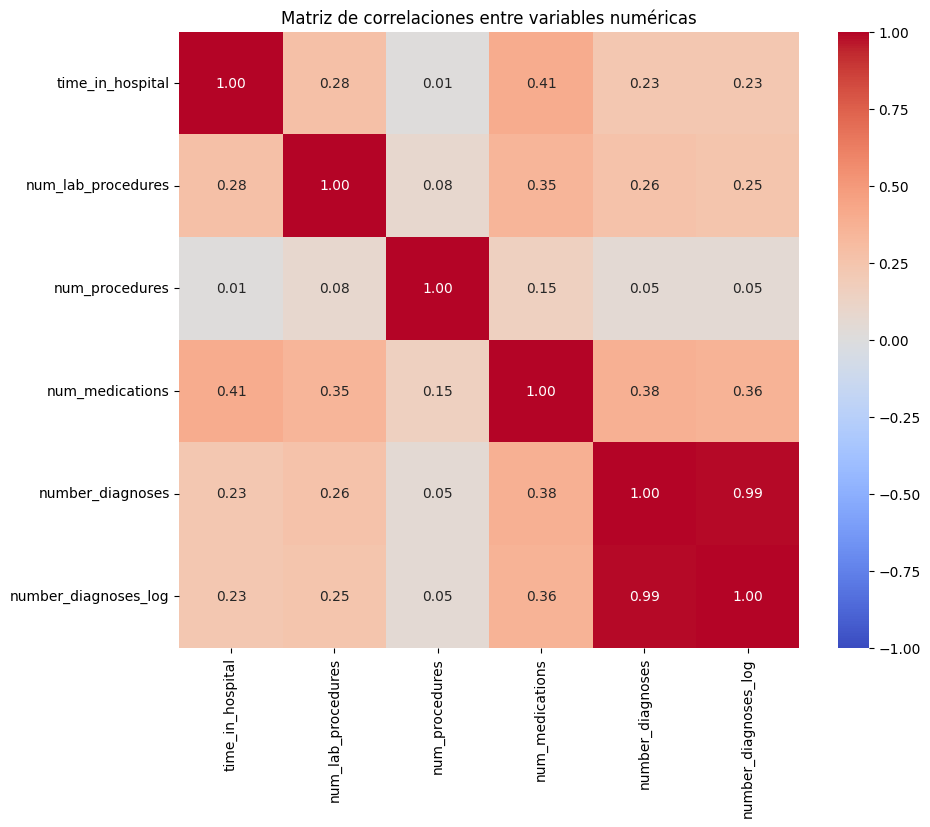

In [66]:
#Matriz de correlación
corr = df_clean[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriz de correlaciones entre variables numéricas")
plt.show()

####
El análisis de correlaciones entre variables numéricas muestra que únicamente existe multicolinealidad fuerte entre **number_diagnoses y number_diagnoses_log (r = 0.99)**, lo que indica redundancia y obliga a descartar una de ellas en fases de modelado. El resto de correlaciones son bajas o moderadas: **destacan** las asociaciones de **num_medications con time_in_hospital**, **num_lab_procedures y number_diagnoses**, lo que resulta clínicamente coherente. No se identifican otras correlaciones críticas (r > 0.8), por lo que la mayoría de variables numéricas aportan información diferenciada.

In [75]:
# Identificar pares con correlación > 0.8
high_corrs = []
for col in corr.columns:
    for row in corr.index:
        if col != row and abs(corr.loc[row, col]) > 0.8:
            pair = tuple(sorted((row, col)))
            if pair not in high_corrs:
                high_corrs.append(pair)

print("Pares de variables con correlación > 0.8:", high_corrs)


Pares de variables con correlación > 0.8: [('number_diagnoses', 'number_diagnoses_log')]


In [68]:
# identificamos con otros valores más bajos.
high_corrs = []
for col in corr.columns:
    for row in corr.index:
        if col != row and abs(corr.loc[row, col]) > 0.47:
            pair = tuple(sorted((row, col)))
            if pair not in high_corrs:
                high_corrs.append(pair)

print("Pares de variables con correlación > 0.47:", high_corrs)

Pares de variables con correlación > 0.47: [('number_diagnoses', 'number_diagnoses_log')]


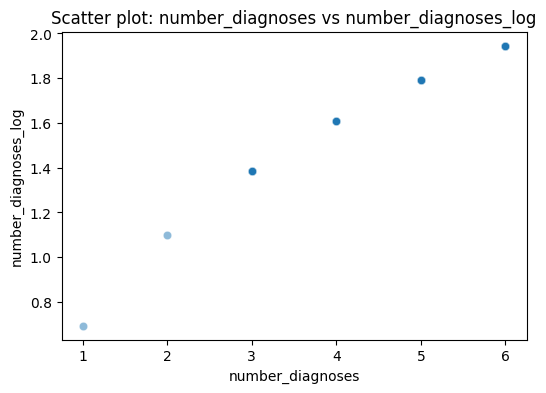

In [69]:
for (x, y) in high_corrs:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df_clean[x], y=df_clean[y], alpha=0.5)
    plt.title(f"Scatter plot: {x} vs {y}")
    plt.show()


####
El scatter plot entre **number_diagnoses y number_diagnoses_log** muestra una relación casi perfecta, ya que la segunda variable es una transformación directa de la primera. Esto confirma la fuerte correlación observada en la matriz (r = 0.99) y evidencia multicolinealidad. En fases de modelado se recomienda conservar únicamente una de las dos variables, preferiblemente la versión logarítmica si la distribución original presenta sesgo, evitando así redundancia en la información.

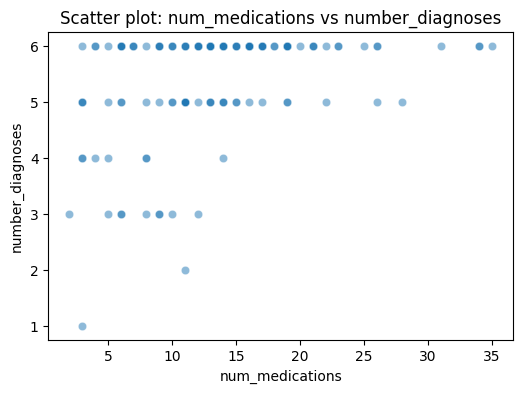

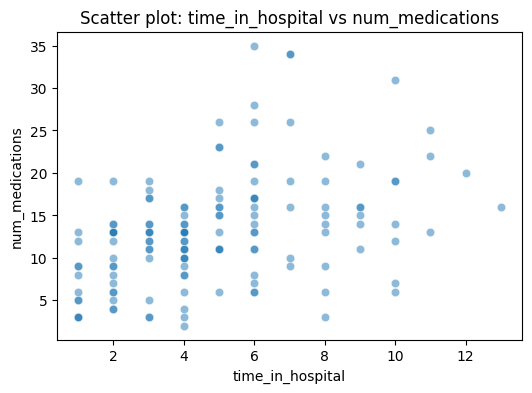

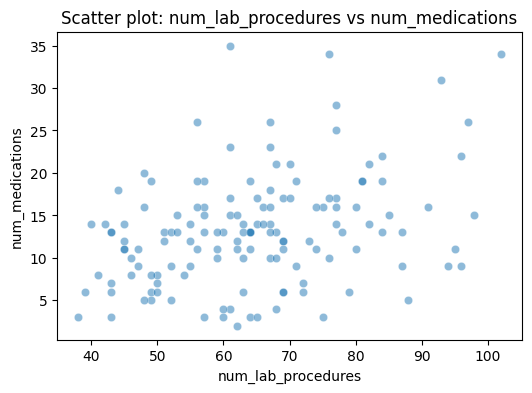

In [76]:
# Seleccionamos algunos pares con correlación moderada para visualizar
pairs_to_plot = [
    ("num_medications", "number_diagnoses"),   
    ("time_in_hospital", "num_medications"),   
    ("num_lab_procedures", "num_medications")  
]

for x, y in pairs_to_plot:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df_clean[x], y=df_clean[y], alpha=0.5)
    plt.title(f"Scatter plot: {x} vs {y}")
    plt.show()


####
Los scatter plots entre variables numéricas confirman asociaciones positivas coherentes clínicamente: a mayor número de diagnósticos y pruebas de laboratorio, así como a mayor tiempo de hospitalización, los pacientes tienden a recibir más medicación. Aunque las relaciones no son muy fuertes **(r entre 0.3 y 0.5)**, son consistentes y aportan información adicional. **Dado que ninguna correlación alcanza valores críticos (r > 0.8), no existe riesgo de multicolinealidad, por lo que todas las variables numéricas pueden conservarse en el análisis posterior**.

# Numérica vs Categórica

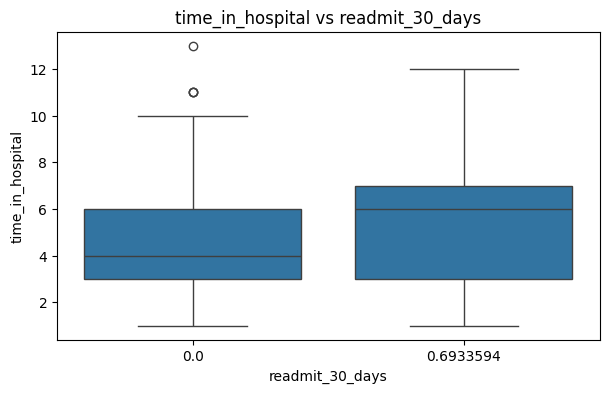

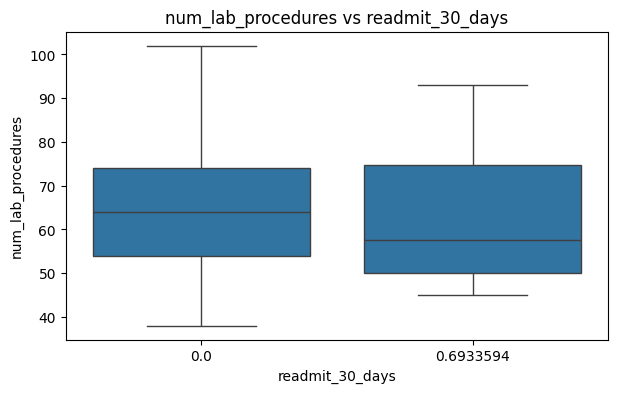

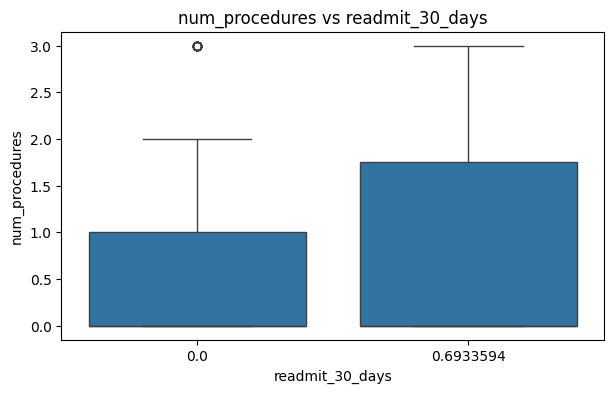

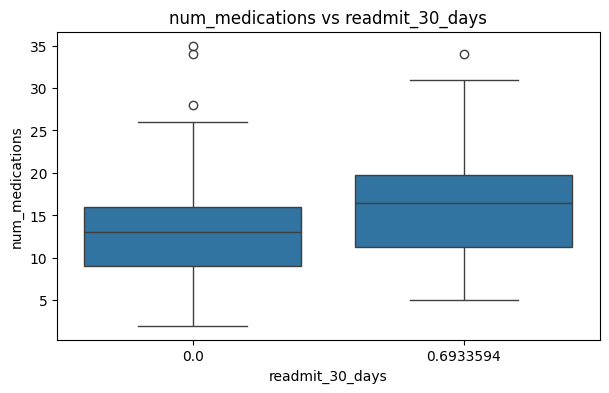

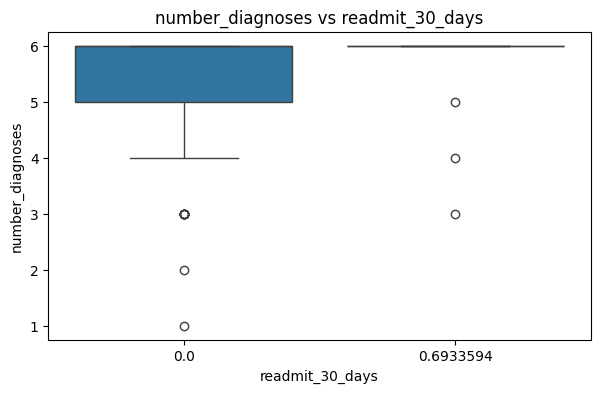

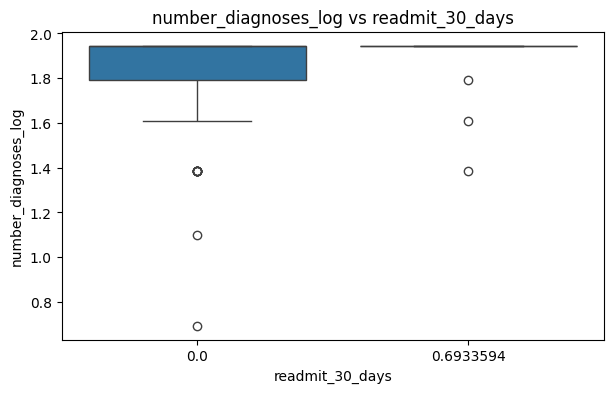

In [71]:
# Numérica vs Categórica
# Seleccionamos algunos pares con correlación moderada para visualizar
num_cols = df_clean.select_dtypes(include=["number"]).drop(columns=["readmit_30_days"]).columns

for col in num_cols:
    plt.figure(figsize=(7,4))
    sns.boxplot(x="readmit_30_days", y=col, data=df_clean)
    plt.title(f"{col} vs readmit_30_days")
    plt.show()


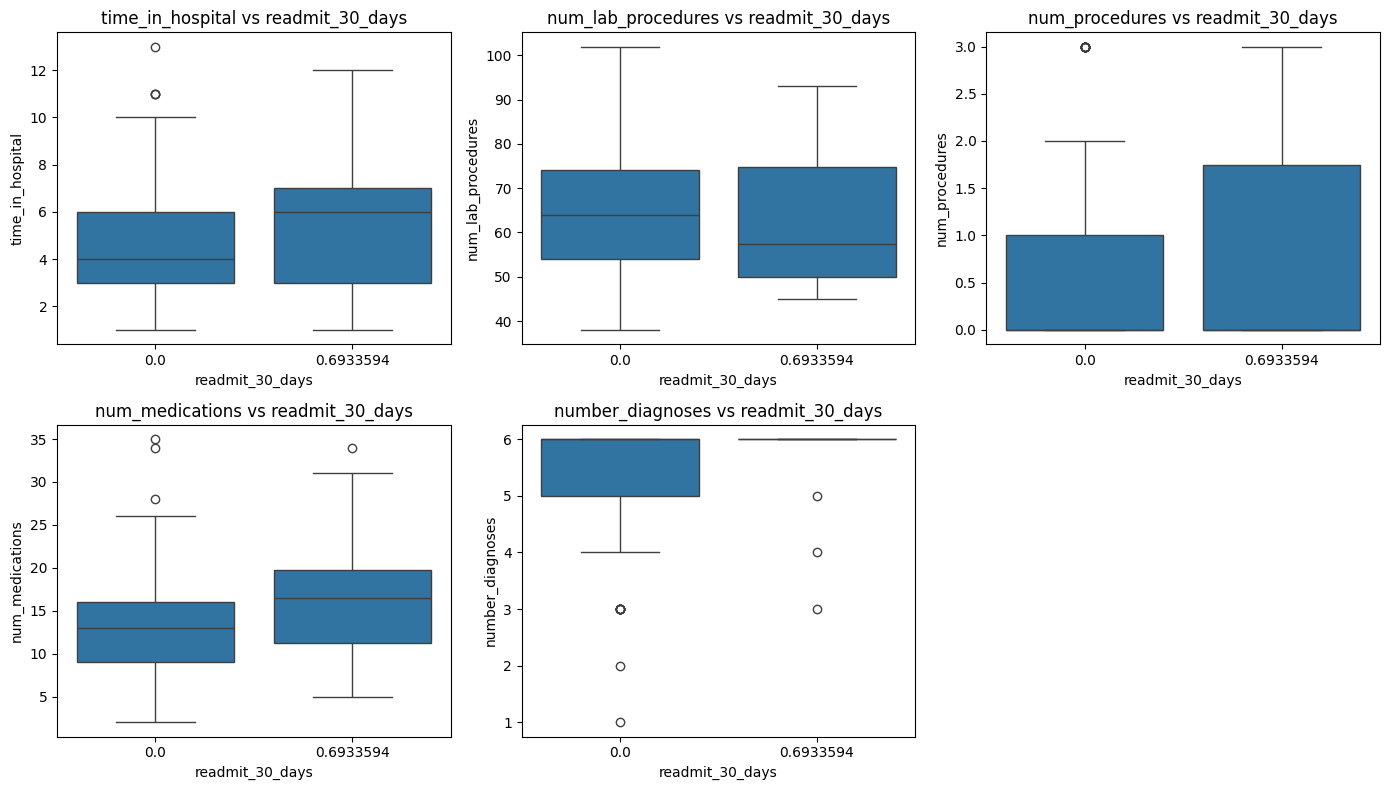

In [78]:
num_cols = ["time_in_hospital", "num_lab_procedures", 
            "num_procedures", "num_medications", "number_diagnoses"]

plt.figure(figsize=(14, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x="readmit_30_days", y=col, data=df_clean)
    plt.title(f"{col} vs readmit_30_days")

plt.tight_layout()
plt.show()


In [80]:
TARGET = "readmit_30_days"  # si tu target se llama distinto, cámbialo aquí

# 1) Selección de categóricas (object, category, bool)
cat_cols = df_clean.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
cat_cols = [c for c in cat_cols if c != TARGET]  # evita el target

# 2) Chi² para cada categórica vs target
rows = []
for col in cat_cols:
    # crosstab (quitamos categorías vacías si las hay)
    tab = pd.crosstab(df_clean[col], df_clean[TARGET])
    if tab.shape[0] < 2 or tab.shape[1] < 2:
        # no tiene al menos 2 categorías o el target no tiene ambas clases
        continue
    chi2, p, dof, exp = chi2_contingency(tab)
    rows.append({"variable": col, "p_value": p, "chi2": chi2, "dof": dof, "levels": tab.shape[0]})

chi_df = pd.DataFrame(rows)
if chi_df.empty:
    raise ValueError("No hay variables categóricas válidas para evaluar con chi².")

# Evita -log10(0): clamp mínimo numérico
eps = 1e-16
chi_df["p_value_clamped"] = chi_df["p_value"].clip(lower=eps)
chi_df["minus_log10_p"] = -np.log10(chi_df["p_value_clamped"])

# Ordena por significancia
chi_df = chi_df.sort_values("p_value").reset_index(drop=True)
display(chi_df)

,variable,p_value,chi2,dof,levels,p_value_clamped,minus_log10_p
0,readmitted,6.554409e-31,139.000000,2,3,1.000000e-16,16.000000
1,readmit_binary,1.913638e-03,9.630584,1,2,1.913638e-03,2.718140
2,discharge_disposition_id,8.754331e-03,6.872272,1,2,8.754331e-03,2.057777
3,gender,2.397971e-01,1.381786,1,2,2.397971e-01,0.620156
4,age,3.504781e-01,2.096914,2,3,3.504781e-01,0.455339
5,had_inpatient_days,3.597348e-01,0.838819,1,2,3.597348e-01,0.444018
6,insulin,4.078067e-01,2.896832,3,4,4.078067e-01,0.389546
7,had_outpatient_days,4.798277e-01,0.499255,1,2,4.798277e-01,0.318915
8,A1Cresult,7.133382e-01,0.675599,2,3,7.133382e-01,0.146705
9,primary_diagnosis,7.898137e-01,1.704975,4,5,7.898137e-01,0.102475


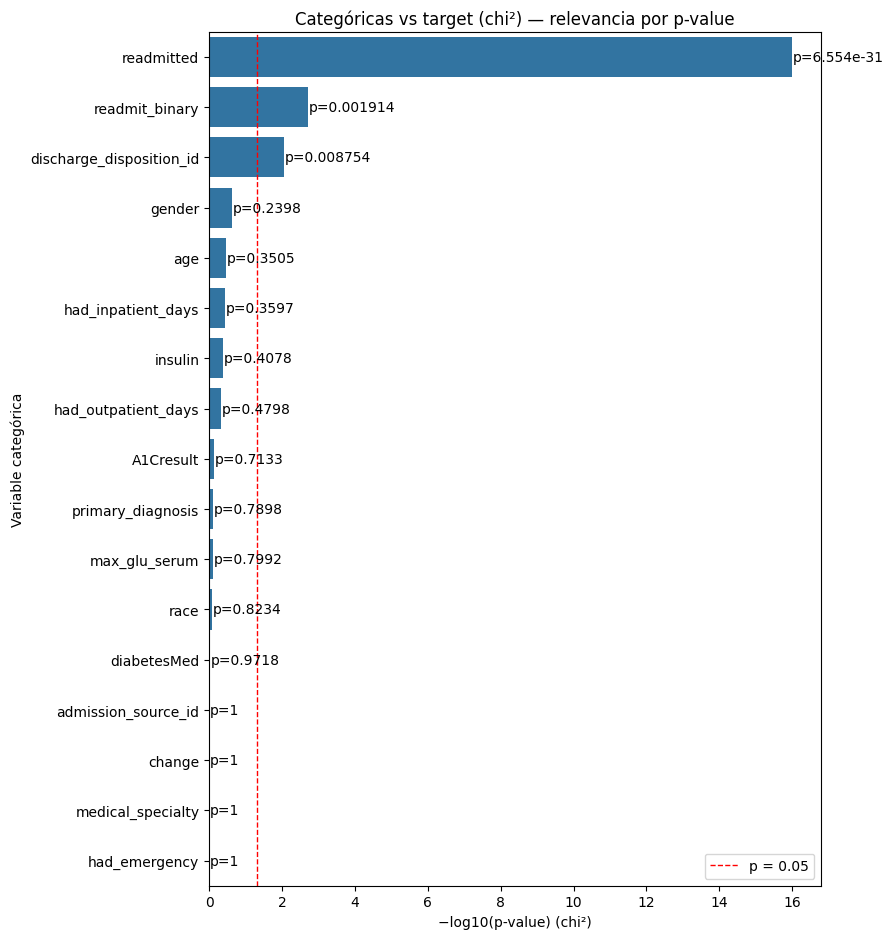

In [81]:
# Visualizamos los datos
plt.figure(figsize=(9, 0.5*len(chi_df)+1))
sns.barplot(
    data=chi_df,
    x="minus_log10_p",
    y="variable",
    orient="h"
)

# Línea de significancia p=0.05
plt.axvline(-np.log10(0.05), color="red", ls="--", lw=1, label="p = 0.05")

# Etiquetas de p sobre las barras
for i, (mlog, p) in enumerate(zip(chi_df["minus_log10_p"], chi_df["p_value"])):
    plt.text(mlog + 0.02, i, f"p={p:.4g}", va="center")

plt.xlabel("−log10(p-value) (chi²)")
plt.ylabel("Variable categórica")
plt.title("Categóricas vs target (chi²) — relevancia por p-value")
plt.legend()
plt.tight_layout()
plt.show()


###
El análisis bivariante categóricas vs objetivo mediante test chi² muestra que únicamente **discharge_disposition_id (tipo de alta hospitalaria) tiene una asociación significativa con la variable readmit_30_days (p < 0.05).** Variables como age, gender, race o factores clínicos (insulin, A1Cresult, diabetesMed) no presentan evidencias suficientes de relación con el reingreso. Estos resultados sugieren que la forma en que un paciente es dado de alta constituye un factor clave en la probabilidad de reingreso, mientras que otros aspectos categóricos analizados aportan escasa relevancia en este conjunto de datos.**Por tanto, la hipótesis de independencia se rechaza únicamente para discharge_disposition_id, confirmando que esta variable categórica está asociada a la probabilidad de reingreso en 30 días. En el resto de casos, no se rechaza la hipótesis nula y no existe evidencia de relación estadísticamente significativa.**